In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/alitaqishah/global-corporate-ghg-emissions-20222023/global_corporate_ghg_emissions_2022_2023.csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import skew, kurtosis, pearsonr
import warnings
warnings.filterwarnings('ignore')

# Machine Learning imports
from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV, cross_validate
from sklearn.preprocessing import StandardScaler, RobustScaler, LabelEncoder
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, RandomForestClassifier
from sklearn.metrics import (
    mean_squared_error, r2_score, mean_absolute_error,
    mean_absolute_percentage_error, classification_report,
    roc_auc_score, confusion_matrix, silhouette_score
)
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA


pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_rows', 100)


available_styles = plt.style.available

if 'seaborn-v0_8-darkgrid' in available_styles:
    plt.style.use('seaborn-v0_8-darkgrid')
elif 'seaborn-darkgrid' in available_styles:
    plt.style.use('seaborn-darkgrid')
else:
    plt.style.use('ggplot')


sns.set_theme(style="darkgrid", palette="husl")

# Global plot settings
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

# Load data

In [3]:




df = pd.read_csv('/kaggle/input/datasets/alitaqishah/global-corporate-ghg-emissions-20222023/global_corporate_ghg_emissions_2022_2023.csv')



In [4]:
print(f"\n Data Loaded: {df.shape[0]} rows, {df.shape[1]} columns")



 Data Loaded: 508 rows, 21 columns


In [5]:
print(f"   Companies: {df['company_id'].nunique()}")


   Companies: 508


In [6]:
print(f"   Countries: {df['country'].nunique()}")


   Countries: 46


In [7]:
print(f"   Years: {sorted(df['reporting_year'].unique())}")

   Years: [np.int64(2021), np.int64(2022), np.int64(2023)]


# Basic statistics

In [8]:


display(df.describe(include='all').round(2))

,company_id,company_name,ticker,country,region,sector,industry,reporting_year,scope1_mt_co2e,scope2_location_mt_co2e,scope2_market_mt_co2e,scope3_total_mt_co2e,scope1_plus_scope2_location_mt,emissions_intensity_mt_per_musd,revenue_usd_millions,reporting_standard,data_source,third_party_verified,net_zero_target_year,notes,data_collection_date
count,508,508,508,508,508,508,508,508.00,508.00,480.00,76.00,23.00,508.00,444.00,444.00,508,508,508,452.00,126,508
unique,508,508,445,46,6,12,131,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11,28,2,NaN,113,1
top,GHG0508,Eversource Energy,—,United States,North America,Materials,Electric Power,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,GHG Protocol,CDP_2023/SustainabilityReport_2023,True,NaN,Privately held,2024-01-01 to 2025-12-31
freq,1,1,58,165,180,146,74,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,400,294,388,NaN,7,508
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2021.99,20.07,1.19,0.74,199.98,21.19,0.00,42702.57,NaN,NaN,NaN,2044.13,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.14,50.32,1.71,1.33,177.11,50.75,0.00,73407.19,NaN,NaN,NaN,9.51,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2021.00,0.05,0.00,0.00,3.00,0.08,0.00,480.00,NaN,NaN,NaN,2025.00,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2022.00,1.20,0.30,0.10,58.00,2.00,0.00,6951.00,NaN,NaN,NaN,2035.00,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2022.00,5.15,0.60,0.11,177.00,6.20,0.00,16563.50,NaN,NaN,NaN,2050.00,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2022.00,17.82,1.40,0.80,263.00,18.82,0.00,45111.25,NaN,NaN,NaN,2050.00,NaN,NaN


# Data quality check

In [9]:

# Unique values per column
for col in df.columns:
    unique_count = df[col].nunique()
    missing_pct = (df[col].isnull().sum() / len(df)) * 100
    print(f"{col:30} | Unique: {unique_count:5} | Missing: {missing_pct:5.1f}%")

company_id                     | Unique:   508 | Missing:   0.0%
company_name                   | Unique:   508 | Missing:   0.0%
ticker                         | Unique:   445 | Missing:   0.0%
country                        | Unique:    46 | Missing:   0.0%
region                         | Unique:     6 | Missing:   0.0%
sector                         | Unique:    12 | Missing:   0.0%
industry                       | Unique:   131 | Missing:   0.0%
reporting_year                 | Unique:     3 | Missing:   0.0%
scope1_mt_co2e                 | Unique:   222 | Missing:   0.0%
scope2_location_mt_co2e        | Unique:    62 | Missing:   5.5%
scope2_market_mt_co2e          | Unique:    26 | Missing:  85.0%
scope3_total_mt_co2e           | Unique:    23 | Missing:  95.5%
scope1_plus_scope2_location_mt | Unique:   278 | Missing:   0.0%
emissions_intensity_mt_per_musd | Unique:   360 | Missing:  12.6%
revenue_usd_millions           | Unique:   438 | Missing:  12.6%
reporting_standard      

# EDA


 Descriptive Statistics:


,company_id,company_name,ticker,country,region,sector,industry,reporting_year,scope1_mt_co2e,scope2_location_mt_co2e,scope2_market_mt_co2e,scope3_total_mt_co2e,scope1_plus_scope2_location_mt,emissions_intensity_mt_per_musd,revenue_usd_millions,reporting_standard,data_source,third_party_verified,net_zero_target_year,notes,data_collection_date
count,508,508,508,508,508,508,508,508.00,508.00,480.00,76.00,23.00,508.00,444.00,444.00,508,508,508,452.00,126,508
unique,508,508,445,46,6,12,131,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11,28,2,NaN,113,1
top,GHG0508,Eversource Energy,—,United States,North America,Materials,Electric Power,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,GHG Protocol,CDP_2023/SustainabilityReport_2023,True,NaN,Privately held,2024-01-01 to 2025-12-31
freq,1,1,58,165,180,146,74,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,400,294,388,NaN,7,508
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2021.99,20.07,1.19,0.74,199.98,21.19,0.00,42702.57,NaN,NaN,NaN,2044.13,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.14,50.32,1.71,1.33,177.11,50.75,0.00,73407.19,NaN,NaN,NaN,9.51,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2021.00,0.05,0.00,0.00,3.00,0.08,0.00,480.00,NaN,NaN,NaN,2025.00,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2022.00,1.20,0.30,0.10,58.00,2.00,0.00,6951.00,NaN,NaN,NaN,2035.00,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2022.00,5.15,0.60,0.11,177.00,6.20,0.00,16563.50,NaN,NaN,NaN,2050.00,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2022.00,17.82,1.40,0.80,263.00,18.82,0.00,45111.25,NaN,NaN,NaN,2050.00,NaN,NaN



 Data Quality Report:


,Column,Data_Type,Missing_%,Unique_Values,Sample_Values
0,company_id,object,0.000000,508,GHG0001
1,company_name,object,0.000000,508,Sasol
2,ticker,object,0.000000,445,SOL
3,country,object,0.000000,46,South Africa
4,region,object,0.000000,6,Africa
5,sector,object,0.000000,12,Materials
6,industry,object,0.000000,131,Chemicals
7,reporting_year,int64,0.000000,3,2022
8,scope1_mt_co2e,float64,0.000000,222,47.3
9,scope2_location_mt_co2e,float64,5.511811,62,2.1


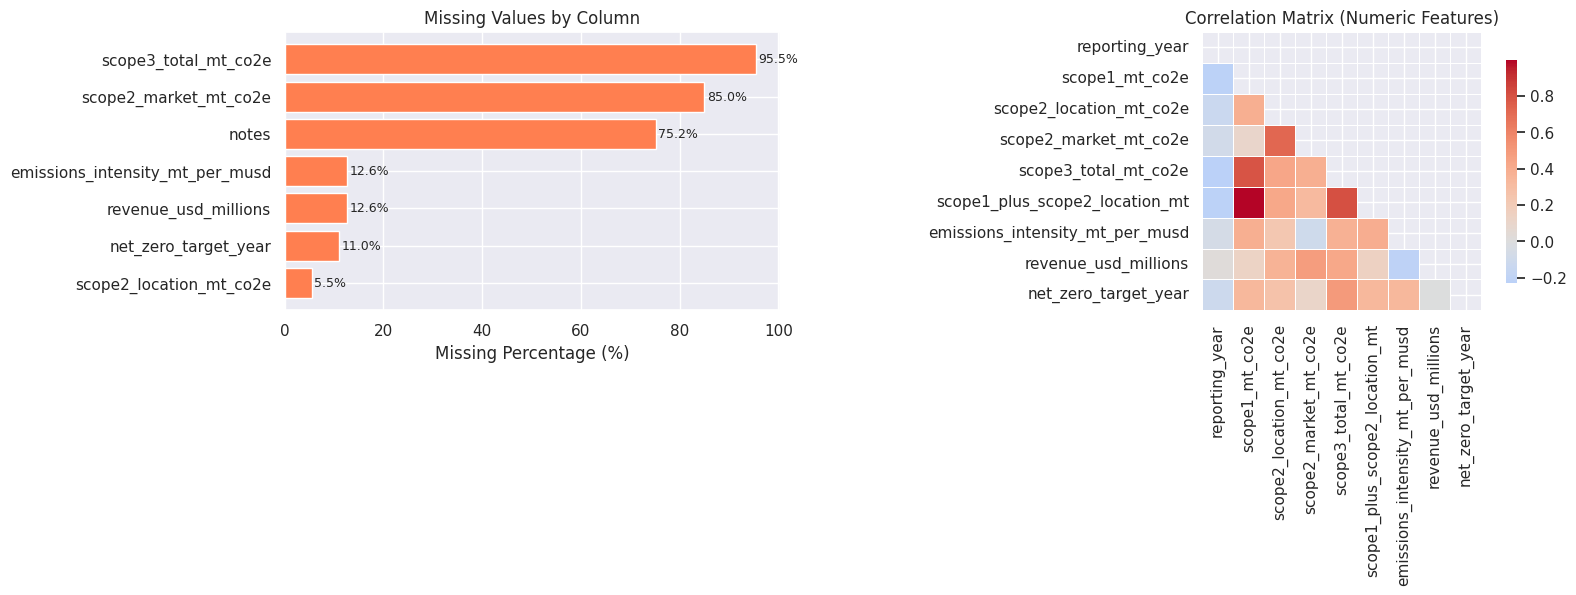

In [10]:

print("\n Descriptive Statistics:")
display(df.describe(include='all').round(2))

# Data quality report
print("\n Data Quality Report:")
quality_report = pd.DataFrame({
    'Column': df.columns,
    'Data_Type': df.dtypes.values,
    'Missing_%': (df.isnull().sum() / len(df) * 100).values,
    'Unique_Values': df.nunique().values,
    'Sample_Values': [str(df[col].dropna().iloc[0])[:50] if df[col].notna().any() else 'NA' for col in df.columns]
})
display(quality_report)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))


#  Missing values plot

ax = axes[0]

missing_pct = (df.isnull().sum() / len(df) * 100)
missing_pct = missing_pct[missing_pct > 0].sort_values()

if not missing_pct.empty:
    bars = ax.barh(missing_pct.index, missing_pct.values, color='coral')

    ax.set_xlabel('Missing Percentage (%)')
    ax.set_title('Missing Values by Column')

    # safer annotation
    for bar in bars:
        width = bar.get_width()
        ax.text(width + 0.5,
                bar.get_y() + bar.get_height() / 2,
                f'{width:.1f}%',
                va='center', fontsize=9)
else:
    ax.text(0.5, 0.5, 'No Missing Values',
            ha='center', va='center', fontsize=12)
    ax.set_axis_off()


#  Correlation heatmap

ax = axes[1]

numeric_cols = df.select_dtypes(include=[np.number]).columns
corr_matrix = df[numeric_cols].corr()

# remove columns with all NaN or constant values (prevents warnings)
corr_matrix = corr_matrix.dropna(axis=0, how='all').dropna(axis=1, how='all')

if corr_matrix.shape[0] > 1:
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

    sns.heatmap(
        corr_matrix,
        mask=mask,
        cmap='coolwarm',
        center=0,
        square=True,
        ax=ax,
        cbar_kws={'shrink': 0.8},
        linewidths=0.5
    )

    ax.set_title('Correlation Matrix (Numeric Features)')
else:
    ax.text(0.5, 0.5, 'Not enough numeric data',
            ha='center', va='center', fontsize=12)
    ax.set_axis_off()

plt.tight_layout()
plt.show()

## Emission variables distribution


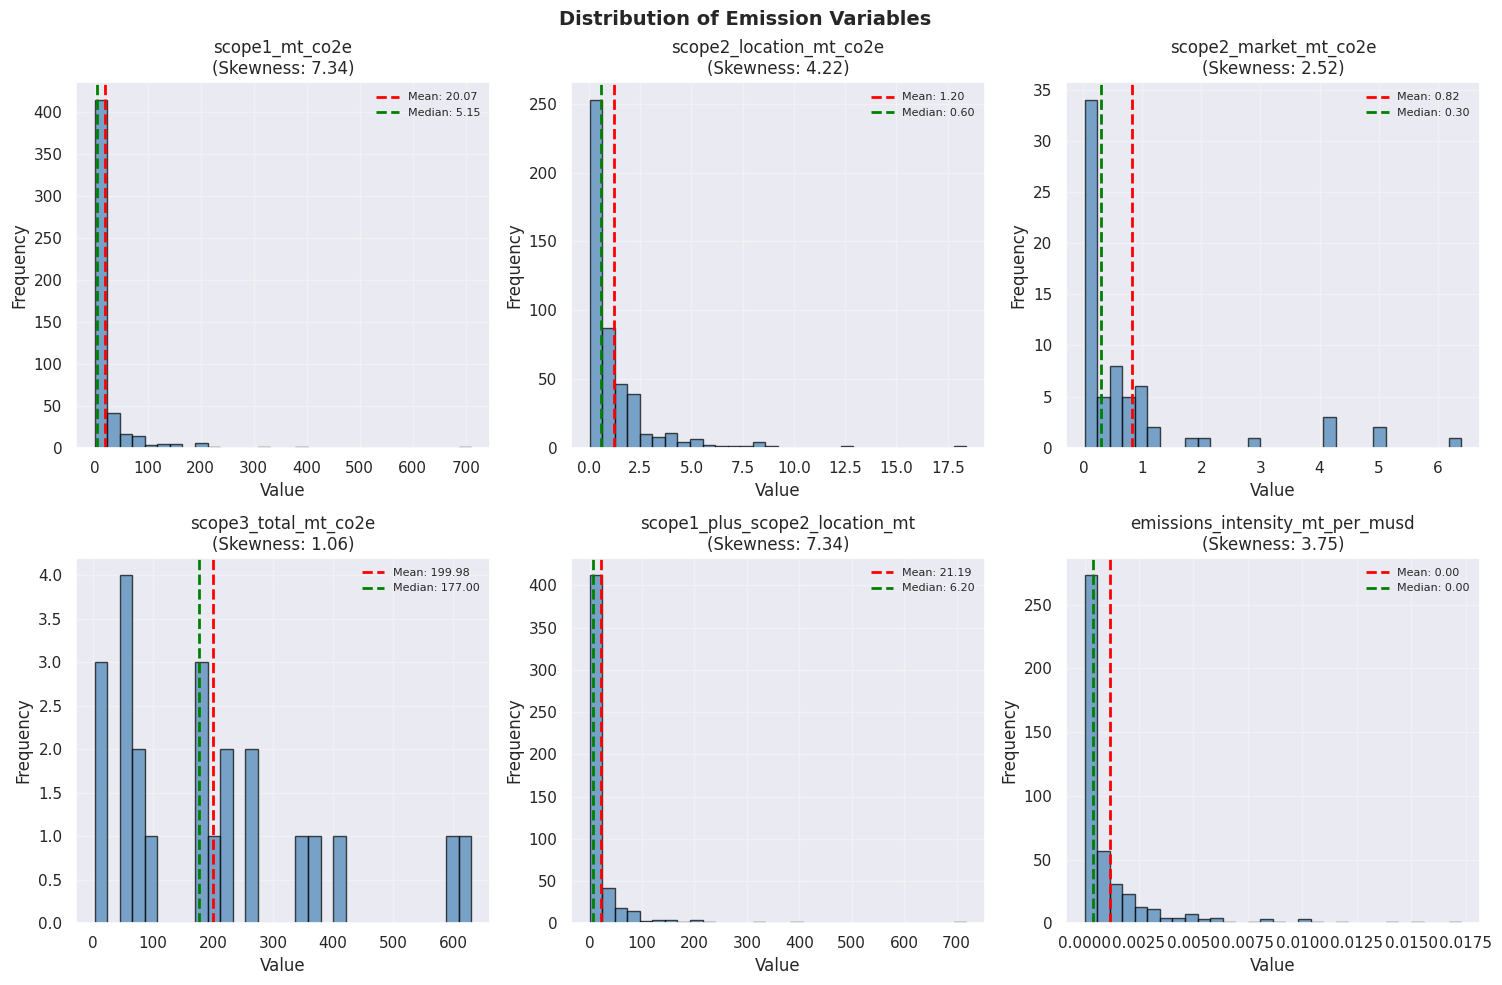

In [11]:


# Emission variables distribution
emission_vars = ['scope1_mt_co2e', 'scope2_location_mt_co2e', 'scope2_market_mt_co2e',
                 'scope3_total_mt_co2e', 'scope1_plus_scope2_location_mt', 'emissions_intensity_mt_per_musd']

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Distribution of Emission Variables', fontsize=14, fontweight='bold')

for idx, var in enumerate(emission_vars):
    row, col = idx // 3, idx % 3
    ax = axes[row, col]
    
    data = df[var].dropna()
    data = data[data > 0] if len(data[data > 0]) > len(data) * 0.5 else data
    
    if len(data) > 0:
        ax.hist(data, bins=30, edgecolor='black', alpha=0.7, color='steelblue')
        ax.axvline(data.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {data.mean():.2f}')
        ax.axvline(data.median(), color='green', linestyle='--', linewidth=2, label=f'Median: {data.median():.2f}')
        ax.set_xlabel('Value')
        ax.set_ylabel('Frequency')
        ax.set_title(f'{var}\n(Skewness: {skew(data):.2f})')
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()



## Log-transformed distributions

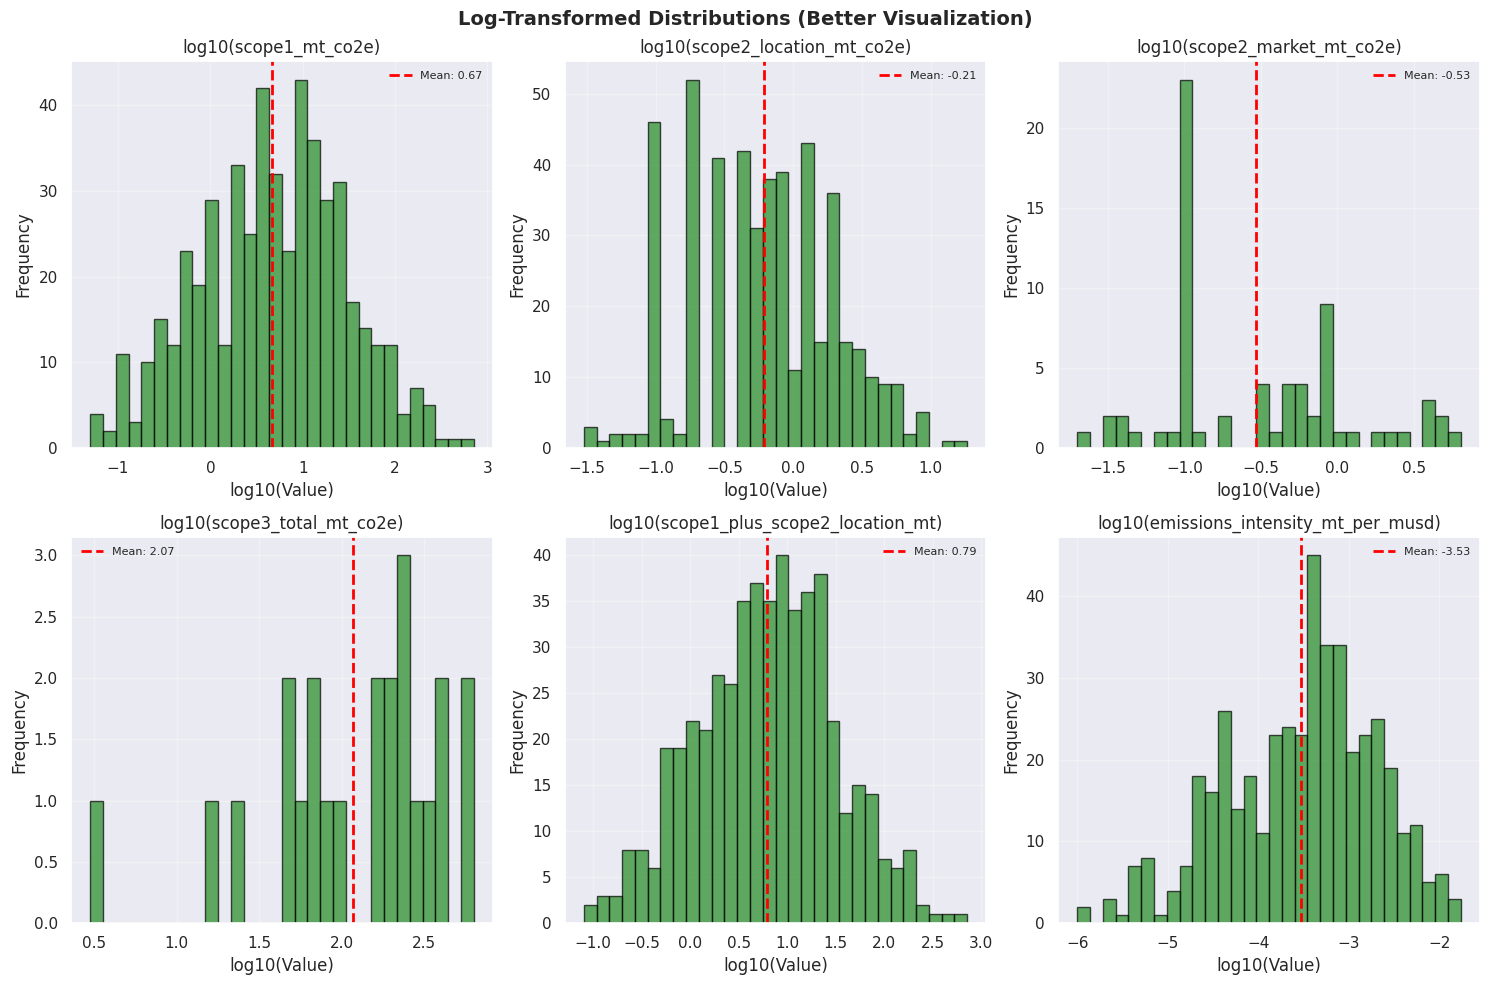

In [12]:

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Log-Transformed Distributions (Better Visualization)', fontsize=14, fontweight='bold')

for idx, var in enumerate(emission_vars):
    row, col = idx // 3, idx % 3
    ax = axes[row, col]
    
    data = df[var].dropna()
    data = data[data > 0]
    
    if len(data) > 0:
        log_data = np.log10(data)
        ax.hist(log_data, bins=30, edgecolor='black', alpha=0.7, color='forestgreen')
        ax.axvline(log_data.mean(), color='red', linestyle='--', linewidth=2, 
                   label=f'Mean: {log_data.mean():.2f}')
        ax.set_xlabel('log10(Value)')
        ax.set_ylabel('Frequency')
        ax.set_title(f'log10({var})')
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## CATEGORICAL VARIABLE ANALYSIS

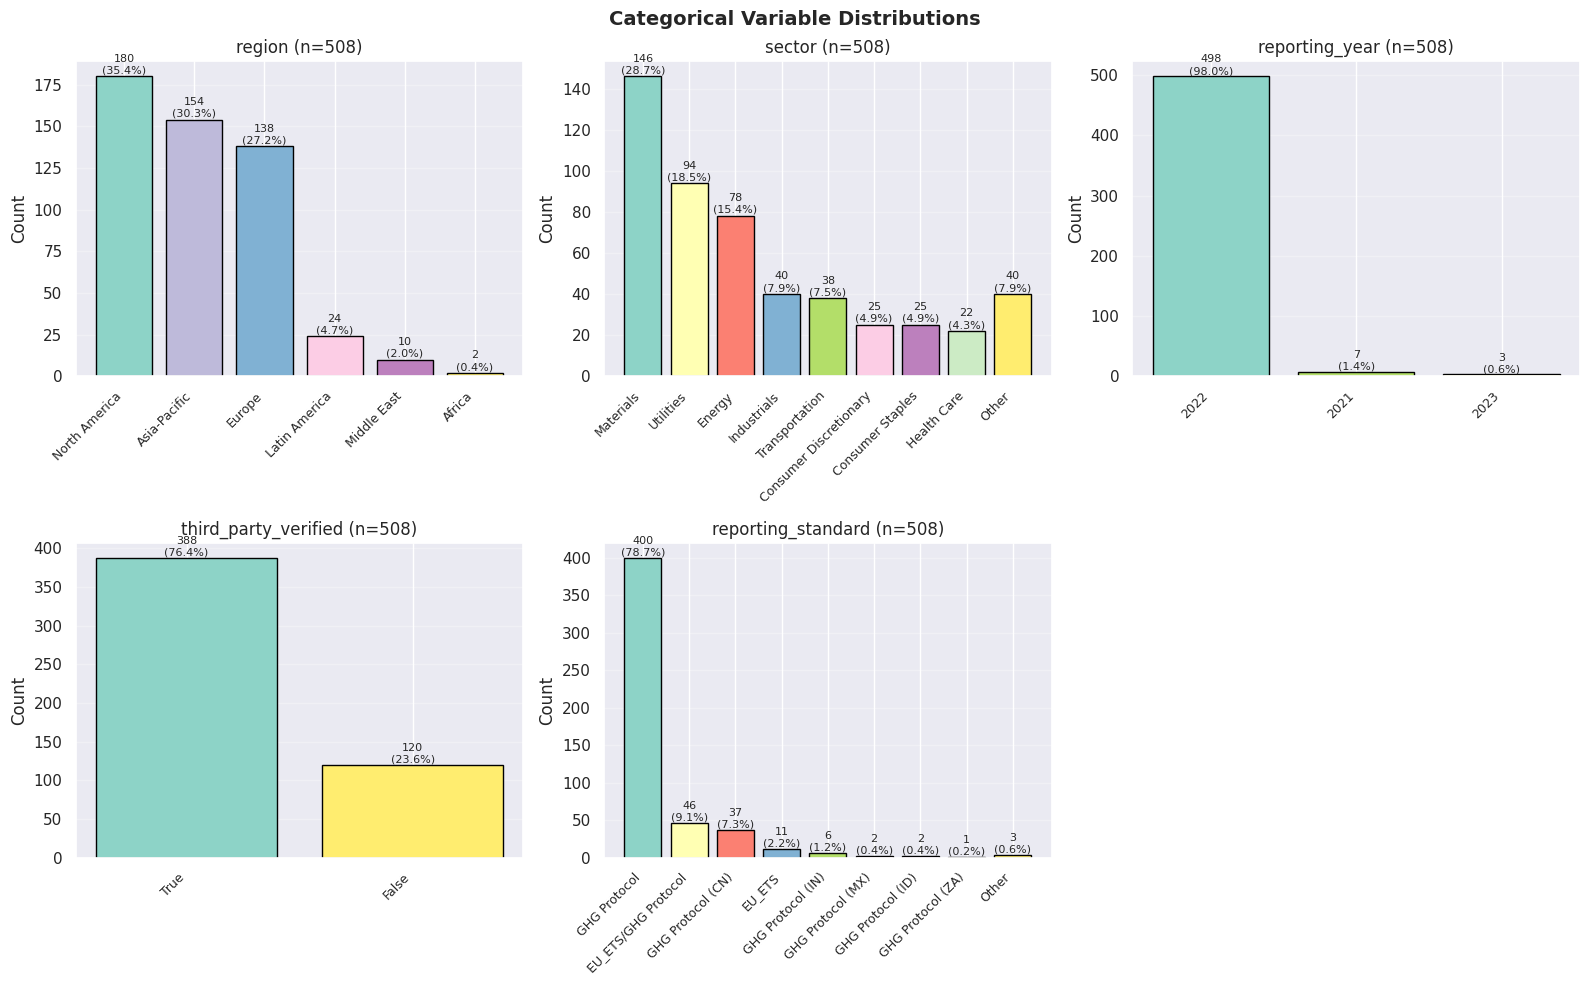

In [13]:


categorical_cols = ['region', 'sector', 'reporting_year', 'third_party_verified', 'reporting_standard']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Categorical Variable Distributions', fontsize=14, fontweight='bold')

for idx, col in enumerate(categorical_cols):
    row, col_idx = idx // 3, idx % 3
    ax = axes[row, col_idx]
    
    value_counts = df[col].value_counts()
    
    # Show top categories
    if len(value_counts) > 8:
        top8 = value_counts.head(8)
        other_sum = value_counts[8:].sum()
        if other_sum > 0:
            top8['Other'] = other_sum
        value_counts = top8
    
    colors = plt.cm.Set3(np.linspace(0, 1, len(value_counts)))
    bars = ax.bar(range(len(value_counts)), value_counts.values, color=colors, edgecolor='black')
    ax.set_xticks(range(len(value_counts)))
    ax.set_xticklabels(value_counts.index, rotation=45, ha='right', fontsize=9)
    ax.set_title(f'{col} (n={len(df)})', fontsize=12)
    ax.set_ylabel('Count')
    ax.grid(True, alpha=0.3, axis='y')
    
    # Add value labels
    for bar, val in zip(bars, value_counts.values):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.5,
                f'{val}\n({val/len(df)*100:.1f}%)', ha='center', va='bottom', fontsize=8)

# Remove empty subplot if any
if len(categorical_cols) < 6:
    for idx in range(len(categorical_cols), 6):
        fig.delaxes(axes[idx // 3, idx % 3])

plt.tight_layout()
plt.show()

## BIVARIATE & MULTIVARIATE ANALYSIS

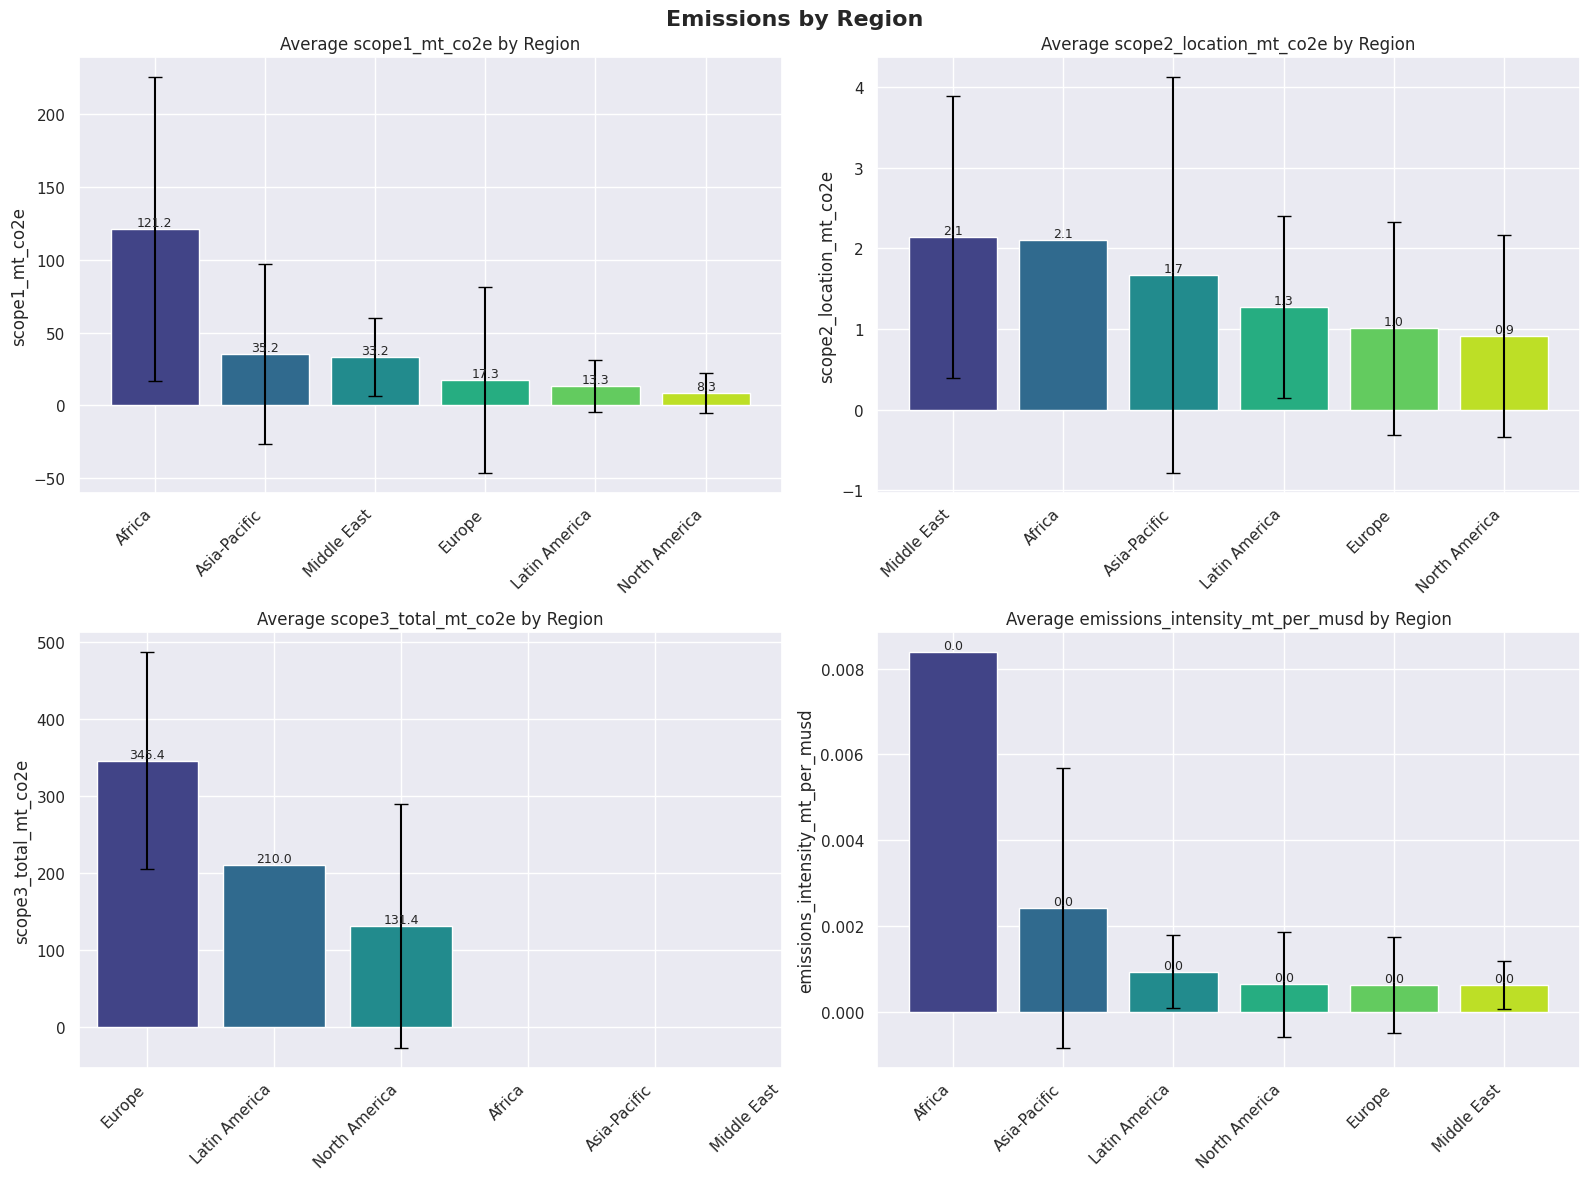

In [14]:
# Emissions by Region
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Emissions by Region', fontsize=16, fontweight='bold')

metrics = ['scope1_mt_co2e', 'scope2_location_mt_co2e', 'scope3_total_mt_co2e', 'emissions_intensity_mt_per_musd']

for idx, metric in enumerate(metrics):
    row, col_idx = idx // 2, idx % 2
    ax = axes[row, col_idx]
    
    # Calculate means by region
    region_means = df.groupby('region')[metric].mean().sort_values(ascending=False)
    
    # Create bar plot with error bars (std)
    region_std = df.groupby('region')[metric].std()
    
    bars = ax.bar(range(len(region_means)), region_means.values, 
                  yerr=region_std[region_means.index].values,
                  capsize=5, color=plt.cm.viridis(np.linspace(0.2, 0.9, len(region_means))))
    
    ax.set_xticks(range(len(region_means)))
    ax.set_xticklabels(region_means.index, rotation=45, ha='right')
    ax.set_title(f'Average {metric} by Region', fontsize=12)
    ax.set_ylabel(metric)
    
    # Add value labels
    for i, (bar, val) in enumerate(zip(bars, region_means.values)):
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height(),
                f'{val:.1f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

##  Emissions by Sector - Heatmap

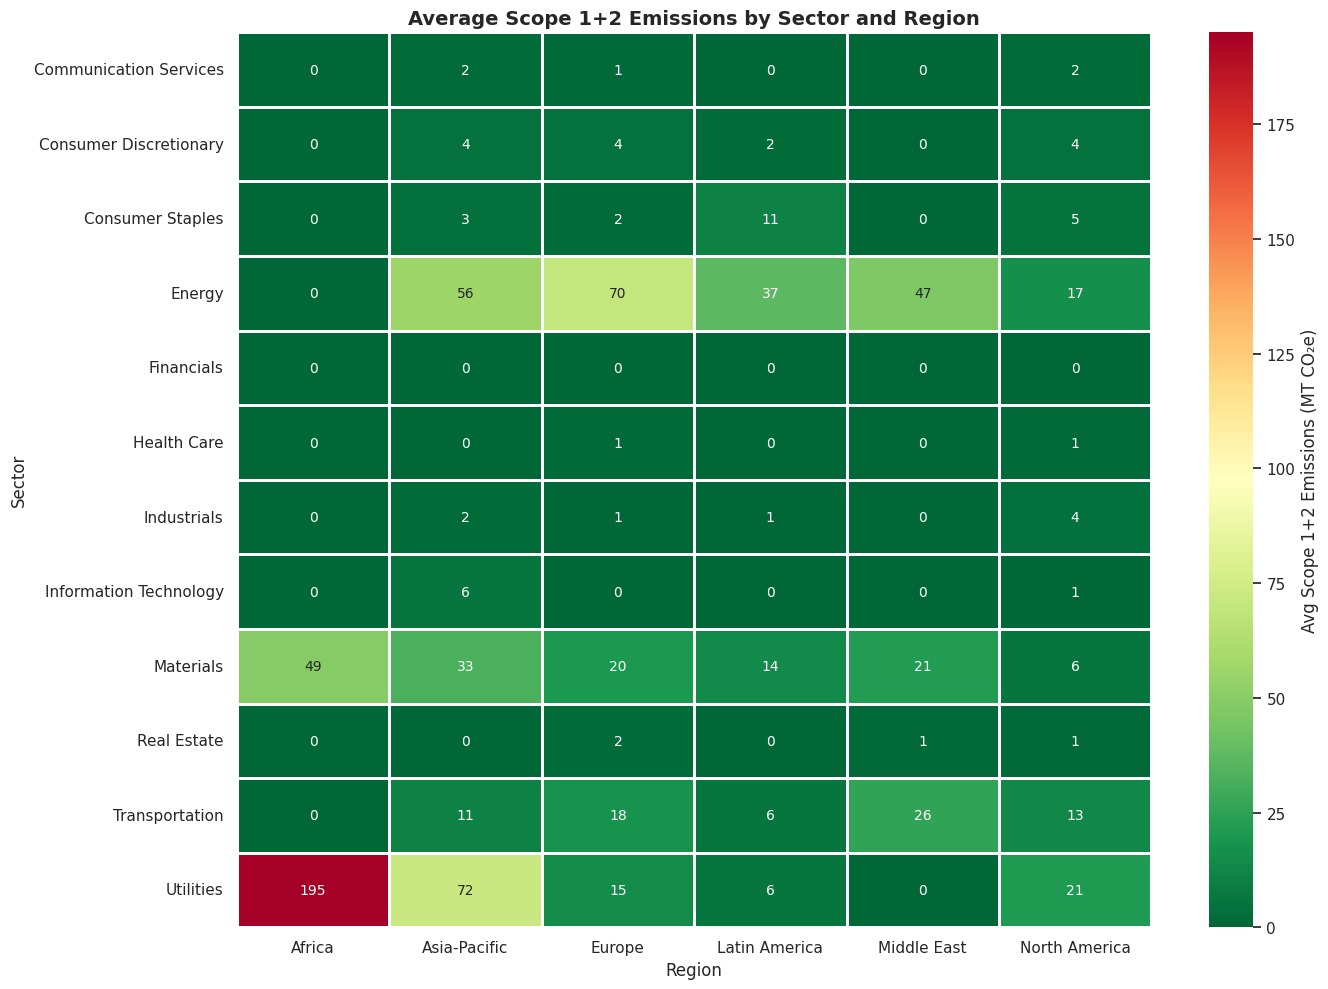

In [15]:

sector_region_pivot = df.pivot_table(
    values='scope1_plus_scope2_location_mt', 
    index='sector', 
    columns='region', 
    aggfunc='mean',
    fill_value=0
)

plt.figure(figsize=(14, 10))
sns.heatmap(sector_region_pivot, annot=True, fmt='.0f', cmap='RdYlGn_r', 
            linewidths=1, linecolor='white', cbar_kws={'label': 'Avg Scope 1+2 Emissions (MT CO₂e)'})
plt.title('Average Scope 1+2 Emissions by Sector and Region', fontsize=14, fontweight='bold')
plt.xlabel('Region', fontsize=12)
plt.ylabel('Sector', fontsize=12)
plt.tight_layout()
plt.show()

##  Emissions by Region and Sector

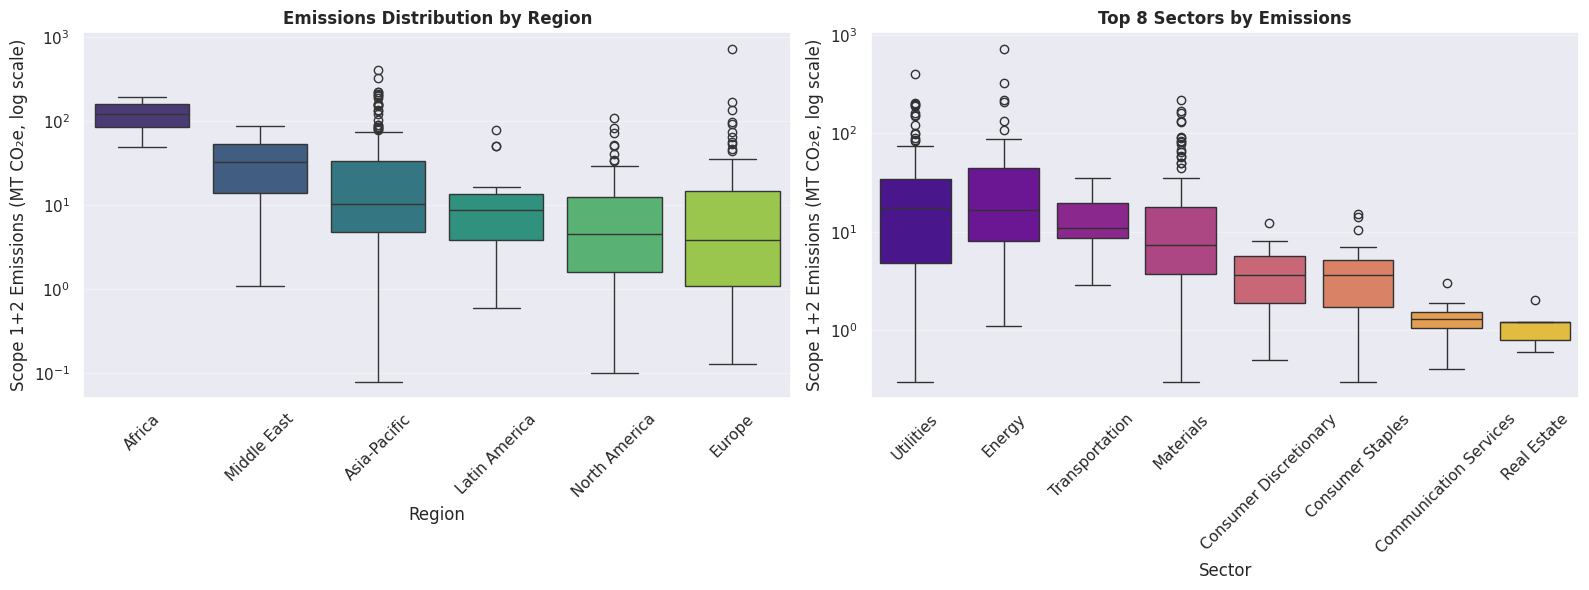

In [16]:


# Emissions by Region and Sector
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Boxplot by region
ax = axes[0]
region_order = df.groupby('region')['scope1_plus_scope2_location_mt'].median().sort_values(ascending=False).index
sns.boxplot(data=df, x='region', y='scope1_plus_scope2_location_mt', order=region_order, ax=ax, palette='viridis')
ax.set_yscale('log')
ax.set_xlabel('Region', fontsize=12)
ax.set_ylabel('Scope 1+2 Emissions (MT CO₂e, log scale)', fontsize=12)
ax.set_title('Emissions Distribution by Region', fontsize=12, fontweight='bold')
ax.tick_params(axis='x', rotation=45)
ax.grid(True, alpha=0.3, axis='y')

# Boxplot by sector
ax = axes[1]
sector_order = df.groupby('sector')['scope1_plus_scope2_location_mt'].median().sort_values(ascending=False).head(8).index
df_sector_filtered = df[df['sector'].isin(sector_order)]
sns.boxplot(data=df_sector_filtered, x='sector', y='scope1_plus_scope2_location_mt', order=sector_order, ax=ax, palette='plasma')
ax.set_yscale('log')
ax.set_xlabel('Sector', fontsize=12)
ax.set_ylabel('Scope 1+2 Emissions (MT CO₂e, log scale)', fontsize=12)
ax.set_title('Top 8 Sectors by Emissions', fontsize=12, fontweight='bold')
ax.tick_params(axis='x', rotation=45)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()




## Correlation analysis

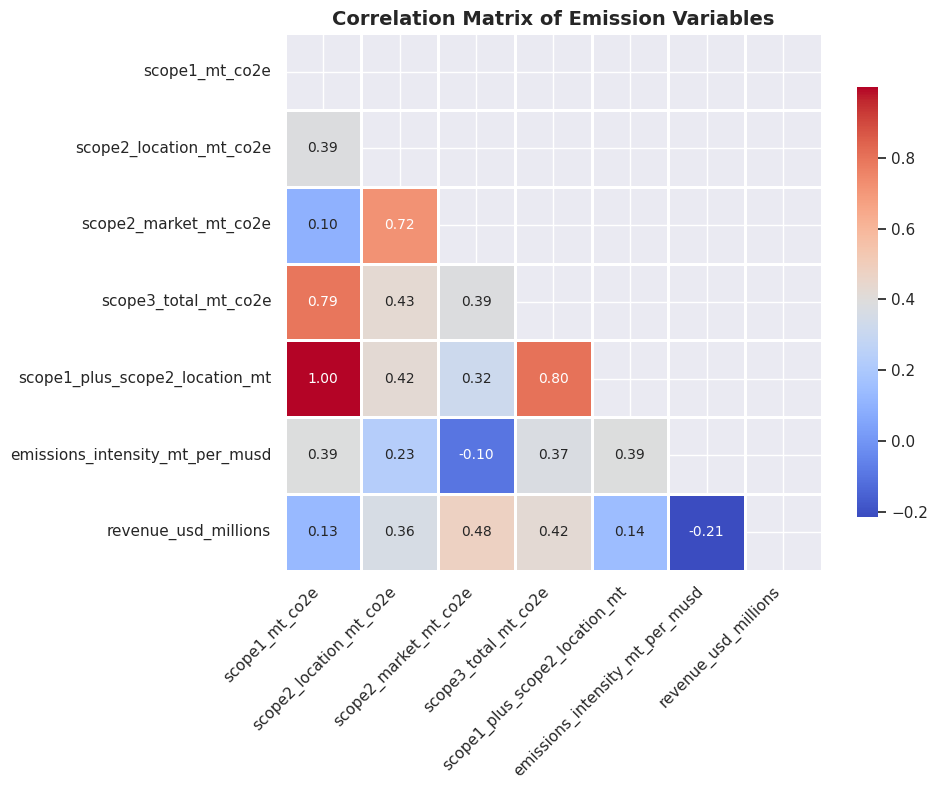


Strong Correlations (>0.7 or <-0.7):
  scope1_mt_co2e ↔ scope3_total_mt_co2e: 0.792
  scope1_mt_co2e ↔ scope1_plus_scope2_location_mt: 0.999
  scope2_location_mt_co2e ↔ scope2_market_mt_co2e: 0.718
  scope3_total_mt_co2e ↔ scope1_plus_scope2_location_mt: 0.805


In [17]:

numeric_cols = ['scope1_mt_co2e', 'scope2_location_mt_co2e', 'scope2_market_mt_co2e',
                'scope3_total_mt_co2e', 'scope1_plus_scope2_location_mt', 
                'emissions_intensity_mt_per_musd', 'revenue_usd_millions']

# Calculate correlations
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            square=True, linewidths=1, cbar_kws={'shrink': 0.8})
plt.title('Correlation Matrix of Emission Variables', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Print strong correlations
print("\nStrong Correlations (>0.7 or <-0.7):")
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i,j]) > 0.7:
            print(f"  {corr_matrix.columns[i]} ↔ {corr_matrix.columns[j]}: {corr_matrix.iloc[i,j]:.3f}")

# TIME SERIES ANALYSIS


Yearly Statistics:


,Emissions_Mean,Emissions_Median,Emissions_Std,Intensity_Mean,Intensity_Median,Company_Count
reporting_year,,,,,,
2021,130.93,27.50,259.64,0.0,0.0,7
2022,19.72,6.00,40.49,0.0,0.0,498
2023,9.52,0.25,16.09,0.0,0.0,3


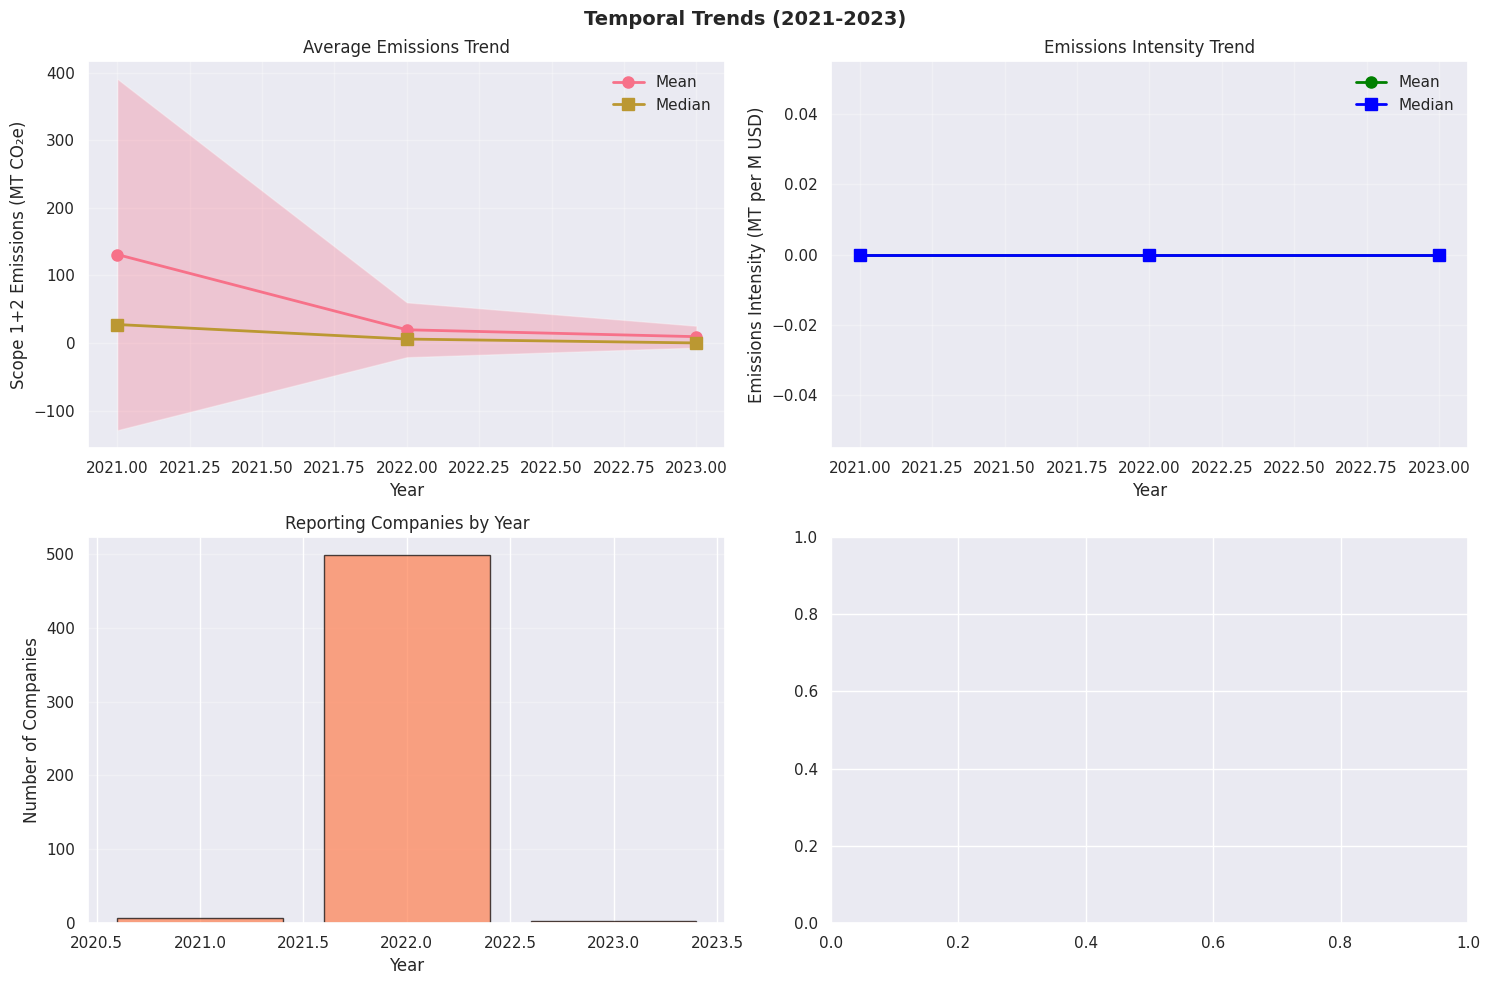

In [18]:

# Prepare time series data
yearly_stats = df.groupby('reporting_year').agg({
    'scope1_plus_scope2_location_mt': ['mean', 'median', 'std'],
    'emissions_intensity_mt_per_musd': ['mean', 'median'],
    'company_id': 'count'
}).round(2)

yearly_stats.columns = ['_'.join(col).strip() for col in yearly_stats.columns.values]
yearly_stats.columns = ['Emissions_Mean', 'Emissions_Median', 'Emissions_Std', 
                        'Intensity_Mean', 'Intensity_Median', 'Company_Count']

print("\nYearly Statistics:")
display(yearly_stats)

# Time series plots
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Temporal Trends (2021-2023)', fontsize=14, fontweight='bold')

# Average emissions trend
ax = axes[0, 0]
years = yearly_stats.index
ax.plot(years, yearly_stats['Emissions_Mean'], marker='o', linewidth=2, markersize=8, label='Mean')
ax.plot(years, yearly_stats['Emissions_Median'], marker='s', linewidth=2, markersize=8, label='Median')
ax.fill_between(years, 
                yearly_stats['Emissions_Mean'] - yearly_stats['Emissions_Std'],
                yearly_stats['Emissions_Mean'] + yearly_stats['Emissions_Std'],
                alpha=0.3)
ax.set_xlabel('Year')
ax.set_ylabel('Scope 1+2 Emissions (MT CO₂e)')
ax.set_title('Average Emissions Trend')
ax.legend()
ax.grid(True, alpha=0.3)

# Emissions intensity trend
ax = axes[0, 1]
ax.plot(years, yearly_stats['Intensity_Mean'], marker='o', linewidth=2, markersize=8, color='green', label='Mean')
ax.plot(years, yearly_stats['Intensity_Median'], marker='s', linewidth=2, markersize=8, color='blue', label='Median')
ax.set_xlabel('Year')
ax.set_ylabel('Emissions Intensity (MT per M USD)')
ax.set_title('Emissions Intensity Trend')
ax.legend()
ax.grid(True, alpha=0.3)

# Company count trend
ax = axes[1, 0]
ax.bar(years, yearly_stats['Company_Count'], edgecolor='black', alpha=0.7, color='coral')
ax.set_xlabel('Year')
ax.set_ylabel('Number of Companies')
ax.set_title('Reporting Companies by Year')
ax.grid(True, alpha=0.3, axis='y')

# Year-over-year changes (for companies with multiple years)
companies_2022 = set(df[df['reporting_year'] == 2022]['company_id'])
companies_2023 = set(df[df['reporting_year'] == 2023]['company_id'])
common_companies = companies_2022.intersection(companies_2023)

if len(common_companies) > 0:
    df_2022 = df[df['reporting_year'] == 2022][['company_id', 'scope1_plus_scope2_location_mt']].set_index('company_id')
    df_2023 = df[df['reporting_year'] == 2023][['company_id', 'scope1_plus_scope2_location_mt']].set_index('company_id')
    
    df_compare = pd.DataFrame({
        '2022': df_2022['scope1_plus_scope2_location_mt'],
        '2023': df_2023['scope1_plus_scope2_location_mt']
    }).dropna()
    
    df_compare['pct_change'] = (df_compare['2023'] - df_compare['2022']) / df_compare['2022'] * 100
    df_compare = df_compare[df_compare['pct_change'].abs() < 200]  # Remove extreme outliers
    
    ax = axes[1, 1]
    ax.hist(df_compare['pct_change'], bins=30, edgecolor='black', alpha=0.7, color='steelblue')
    ax.axvline(0, color='red', linestyle='--', linewidth=2)
    ax.axvline(df_compare['pct_change'].mean(), color='green', linestyle='--', 
               linewidth=2, label=f'Mean: {df_compare["pct_change"].mean():.1f}%')
    ax.set_xlabel('Year-over-Year Change (%)')
    ax.set_ylabel('Number of Companies')
    ax.set_title(f'Emissions Change (2022→2023)\nn={len(df_compare)} companies')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Emissions by sector and verification status

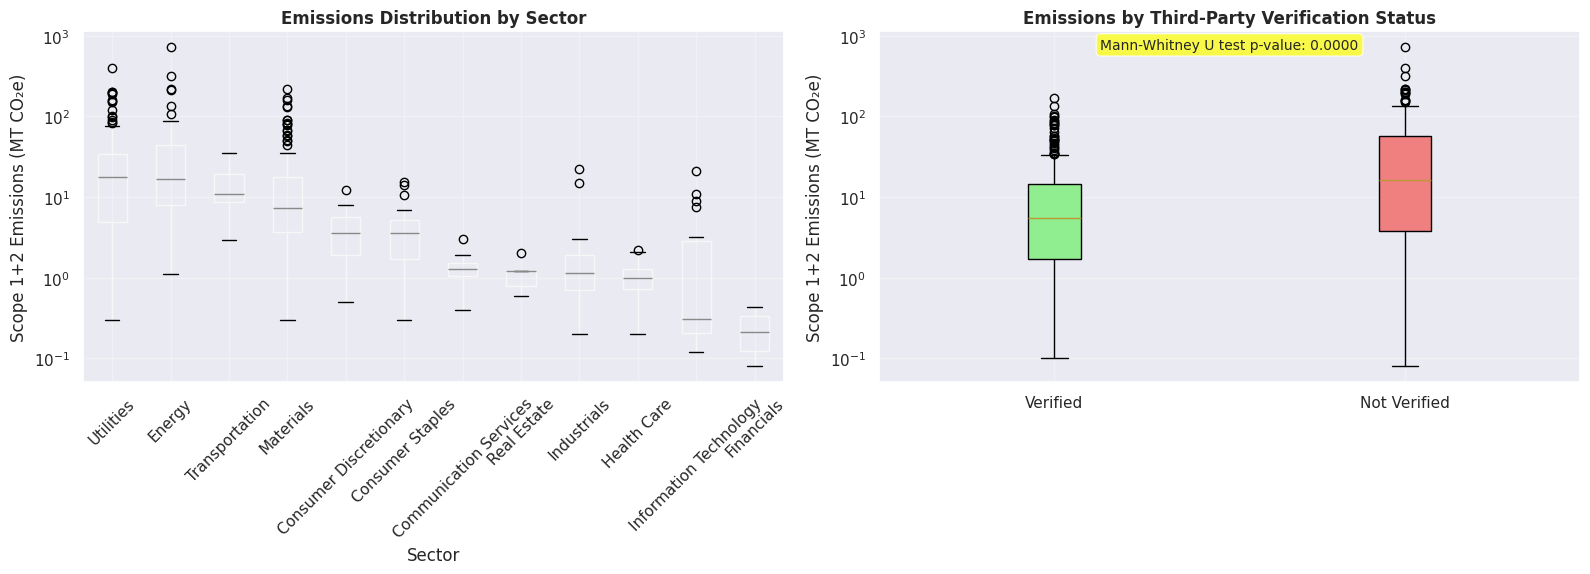

In [19]:

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Boxplot 1: Emissions by sector
sector_order = df.groupby('sector')['scope1_plus_scope2_location_mt'].median().sort_values(ascending=False).index
df_sorted = df.copy()
df_sorted['sector'] = pd.Categorical(df['sector'], categories=sector_order, ordered=True)

ax = axes[0]
df_sorted.boxplot(column='scope1_plus_scope2_location_mt', by='sector', ax=ax)
ax.set_title('Emissions Distribution by Sector', fontsize=12, fontweight='bold')
ax.set_xlabel('Sector')
ax.set_ylabel('Scope 1+2 Emissions (MT CO₂e)')
ax.set_yscale('log')
ax.tick_params(axis='x', rotation=45)
ax.grid(True, alpha=0.3)

#  Emissions by verification status
ax = axes[1]
verified_data = [df[df['third_party_verified'] == True]['scope1_plus_scope2_location_mt'].dropna(),
                 df[df['third_party_verified'] == False]['scope1_plus_scope2_location_mt'].dropna()]
bp = ax.boxplot(verified_data, labels=['Verified', 'Not Verified'], patch_artist=True)
bp['boxes'][0].set_facecolor('lightgreen')
bp['boxes'][1].set_facecolor('lightcoral')
ax.set_title('Emissions by Third-Party Verification Status', fontsize=12, fontweight='bold')
ax.set_ylabel('Scope 1+2 Emissions (MT CO₂e)')
ax.set_yscale('log')
ax.grid(True, alpha=0.3)

# Statistical test
from scipy.stats import mannwhitneyu
stat, p_value = mannwhitneyu(verified_data[0], verified_data[1], alternative='two-sided')
ax.text(0.5, 0.95, f'Mann-Whitney U test p-value: {p_value:.4f}', 
        transform=ax.transAxes, ha='center', fontsize=10,
        bbox=dict(boxstyle="round,pad=0.3", facecolor="yellow", alpha=0.7))

plt.suptitle('')  # Remove automatic suptitle
plt.tight_layout()
plt.show()

##  Revenue vs Emissions with sector coloring

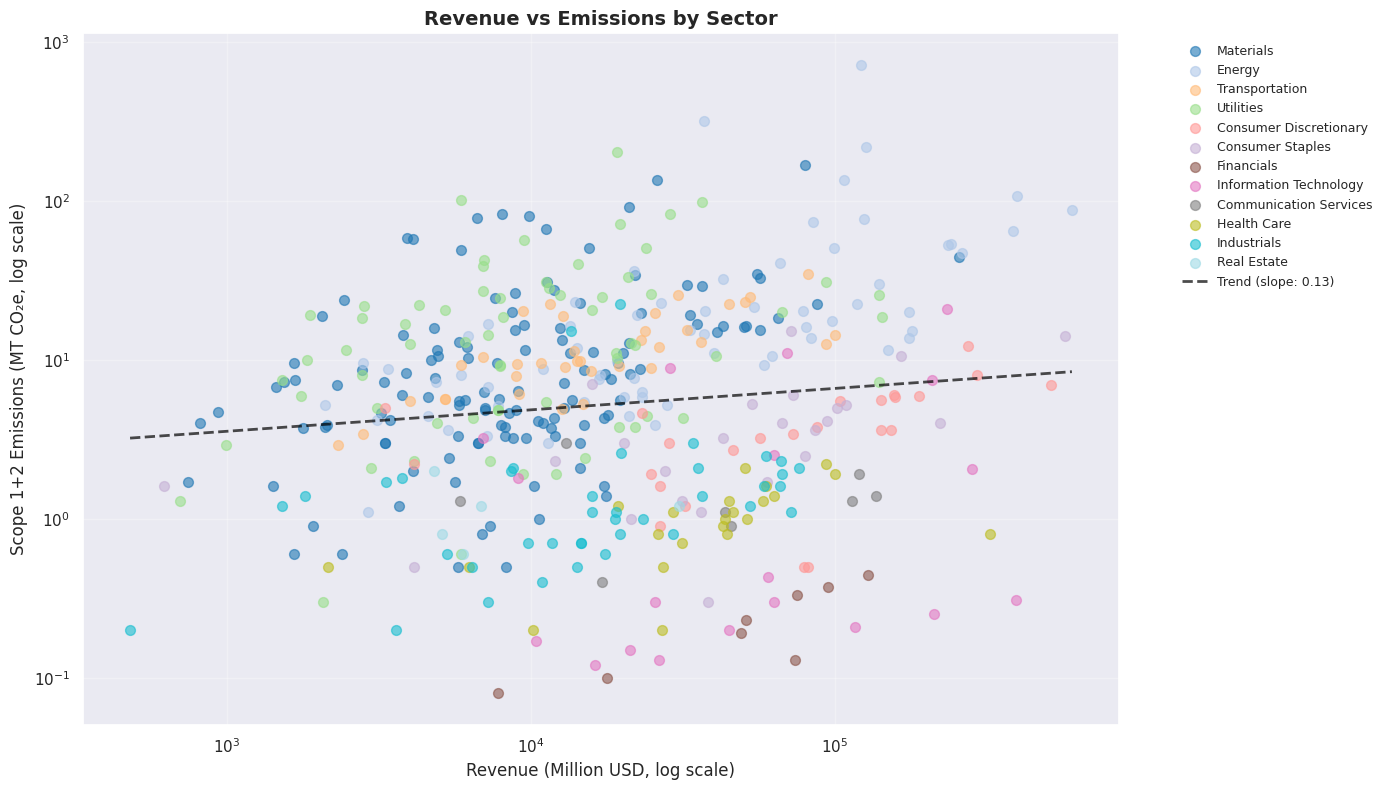

In [20]:

plt.figure(figsize=(14, 8))

# Clean dataset 
clean_df = df[['sector', 'revenue_usd_millions', 'scope1_plus_scope2_location_mt']].copy()
clean_df = clean_df.dropna()

# Remove invalid values for log scale
clean_df = clean_df[
    (clean_df['revenue_usd_millions'] > 0) &
    (clean_df['scope1_plus_scope2_location_mt'] > 0)
]

# Color mapping per sector
sectors = clean_df['sector'].unique()
colors = plt.cm.tab20(np.linspace(0, 1, len(sectors)))

for sector, color in zip(sectors, colors):
    sector_data = clean_df[clean_df['sector'] == sector]
    plt.scatter(
        sector_data['revenue_usd_millions'],
        sector_data['scope1_plus_scope2_location_mt'],
        label=sector,
        alpha=0.6,
        s=50,
        color=color
    )

# Log scales
plt.xscale('log')
plt.yscale('log')

plt.xlabel('Revenue (Million USD, log scale)', fontsize=12)
plt.ylabel('Scope 1+2 Emissions (MT CO₂e, log scale)', fontsize=12)
plt.title('Revenue vs Emissions by Sector', fontsize=14, fontweight='bold')

plt.grid(True, alpha=0.3)


# Trend line 

x = clean_df['revenue_usd_millions']
y = clean_df['scope1_plus_scope2_location_mt']

# log transform
log_x = np.log10(x)
log_y = np.log10(y)

# regression
z = np.polyfit(log_x, log_y, 1)
p = np.poly1d(z)

# line for visualization
x_line = np.logspace(np.log10(x.min()), np.log10(x.max()), 100)

plt.plot(
    x_line,
    10 ** p(np.log10(x_line)),
    'k--',
    alpha=0.7,
    linewidth=2,
    label=f'Trend (slope: {z[0]:.2f})'
)

# Legend (single, clean)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)

plt.tight_layout()
plt.show()

# FEATURE ENGINEERING

In [21]:

# Create clean dataset
df_model = df.copy()

#  SAFE FEATURES (derived from non-target variables)
df_model['has_verification'] = df_model['third_party_verified'].fillna(False).astype(int)
df_model['has_net_zero_target'] = df_model['net_zero_target_year'].notna().astype(int)
df_model['is_high_emitting_sector'] = df_model['sector'].isin(['Utilities', 'Energy', 'Materials']).astype(int)

# Time-based features
df_model['years_since_2021'] = df_model['reporting_year'] - 2021

# Revenue features (safe - independent)
df_model['log_revenue'] = np.log1p(df_model['revenue_usd_millions'].fillna(df_model['revenue_usd_millions'].median()))

# Create interaction features from safe features only
df_model['revenue_verification_interaction'] = df_model['log_revenue'] * df_model['has_verification']
df_model['revenue_target_interaction'] = df_model['log_revenue'] * df_model['has_net_zero_target']

# Sector and region indicators (safe)
df_model = pd.get_dummies(df_model, columns=['sector', 'region'], prefix=['sector', 'region'], drop_first=True)

# Define feature columns 
safe_feature_cols = [
    'log_revenue',
    'reporting_year',
    'years_since_2021',
    'has_verification',
    'has_net_zero_target',
    'is_high_emitting_sector',
    'revenue_verification_interaction',
    'revenue_target_interaction'
]

# Add one-hot encoded columns
encoded_cols = [col for col in df_model.columns if col.startswith(('sector_', 'region_'))]
safe_feature_cols.extend(encoded_cols)

# Target variable
target_col = 'scope1_plus_scope2_location_mt'

print(f" Created {len(safe_feature_cols)} safe features (no leakage)")
print(f"   Features: {', '.join(safe_feature_cols[:8])}...")
print(f"   Total features after encoding: {len(safe_feature_cols)}")

# Prepare data
X = df_model[safe_feature_cols].copy()
y = df_model[target_col].values

# Remove missing values
valid_mask = ~(X.isna().any(axis=1) | pd.isna(y))
X = X[valid_mask]
y = y[valid_mask]

print(f"\n Model-ready dataset:")
print(f"   Samples: {X.shape[0]}")
print(f"   Features: {X.shape[1]}")
print(f"   Target range: {y.min():.2f} - {y.max():.2f} MT CO₂e")

 Created 24 safe features (no leakage)
   Features: log_revenue, reporting_year, years_since_2021, has_verification, has_net_zero_target, is_high_emitting_sector, revenue_verification_interaction, revenue_target_interaction...
   Total features after encoding: 24

 Model-ready dataset:
   Samples: 508
   Features: 24
   Target range: 0.08 - 718.20 MT CO₂e


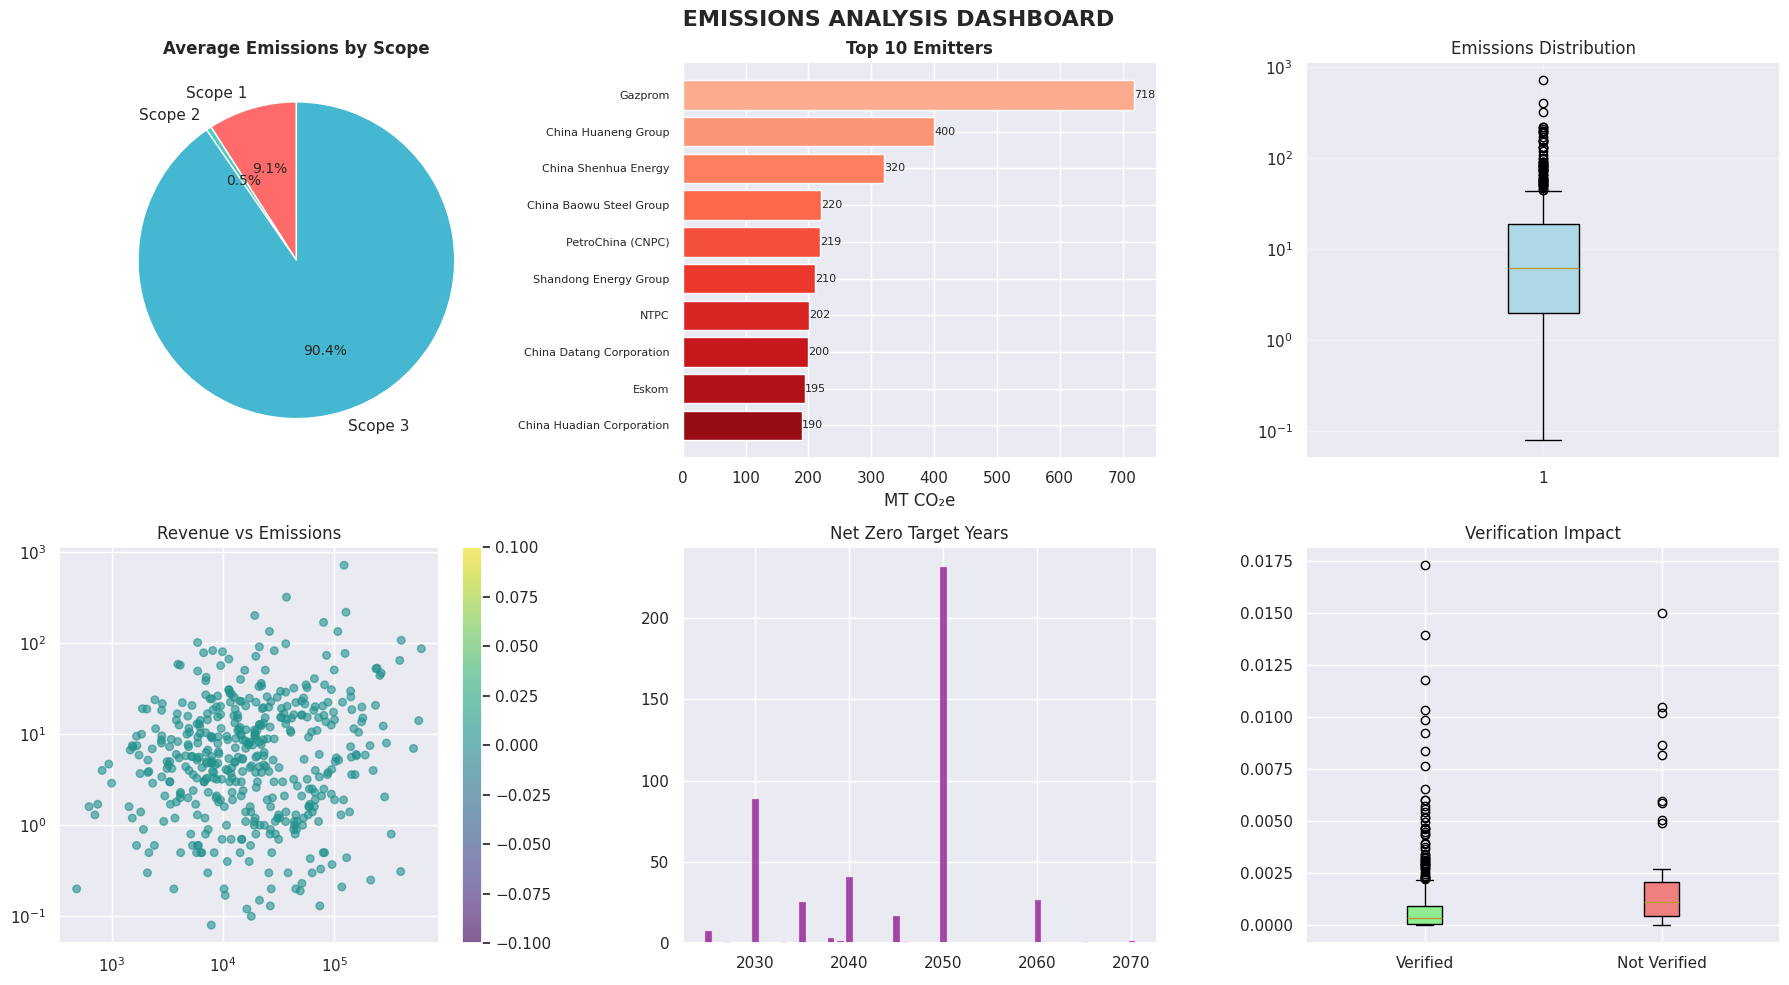

In [22]:


fig = plt.figure(figsize=(18, 10))


#  Scope Pie Chart

ax1 = plt.subplot(2, 3, 1)

scope_data = [
    df['scope1_mt_co2e'].mean(),
    df['scope2_location_mt_co2e'].mean(),
    df['scope3_total_mt_co2e'].mean()
]

colors_pie = ['#FF6B6B', '#4ECDC4', '#45B7D1']
ax1.pie(scope_data,
        labels=['Scope 1', 'Scope 2', 'Scope 3'],
        autopct='%1.1f%%',
        colors=colors_pie,
        startangle=90)

ax1.set_title('Average Emissions by Scope', fontweight='bold')


#  Top 10 Emitters

ax2 = plt.subplot(2, 3, 2)

top10 = df.nlargest(10, 'scope1_plus_scope2_location_mt')
colors = plt.cm.Reds(np.linspace(0.3, 0.9, 10))

bars = ax2.barh(
    range(len(top10)),
    top10['scope1_plus_scope2_location_mt'],
    color=colors
)

ax2.set_yticks(range(len(top10)))
ax2.set_yticklabels(top10['company_name'].astype(str).str[:30], fontsize=8)
ax2.set_xlabel('MT CO₂e')
ax2.set_title('Top 10 Emitters', fontweight='bold')
ax2.invert_yaxis()

for bar in bars:
    val = bar.get_width()
    ax2.text(val, bar.get_y() + bar.get_height()/2,
             f'{val:.0f}', va='center', fontsize=8)


# Boxplot

ax3 = plt.subplot(2, 3, 3)

bp = ax3.boxplot(df['scope1_plus_scope2_location_mt'].dropna(),
                 patch_artist=True)

bp['boxes'][0].set_facecolor('lightblue')

ax3.set_title('Emissions Distribution')
ax3.set_yscale('log')
ax3.grid(True, alpha=0.3)


#  Scatter

ax4 = plt.subplot(2, 3, 4)

# SAFE check for column
if 'has_net_zero_target' in df.columns:
    color_data = df['has_net_zero_target'].fillna(0)
else:
    color_data = np.zeros(len(df))  # fallback

scatter = ax4.scatter(
    df['revenue_usd_millions'],
    df['scope1_plus_scope2_location_mt'],
    c=color_data,
    cmap='viridis',
    alpha=0.6,
    s=30
)

ax4.set_xscale('log')
ax4.set_yscale('log')
ax4.set_title('Revenue vs Emissions')

plt.colorbar(scatter, ax=ax4)


#  Net Zero Target Years 

ax5 = plt.subplot(2, 3, 5)

if 'net_zero_target_year' in df.columns:
    target_years = df['net_zero_target_year'].dropna().value_counts().sort_index()

    if not target_years.empty:
        ax5.bar(target_years.index, target_years.values,
                color='purple', alpha=0.7)

ax5.set_title('Net Zero Target Years')


#  Verification Impact

ax6 = plt.subplot(2, 3, 6)

if 'third_party_verified' in df.columns and 'emissions_intensity_mt_per_musd' in df.columns:

    verified = df[df['third_party_verified'] == True]['emissions_intensity_mt_per_musd'].dropna()
    not_verified = df[df['third_party_verified'] == False]['emissions_intensity_mt_per_musd'].dropna()

    bp2 = ax6.boxplot([verified, not_verified],
                      labels=['Verified', 'Not Verified'],
                      patch_artist=True)

    if len(bp2['boxes']) > 0:
        bp2['boxes'][0].set_facecolor('lightgreen')
    if len(bp2['boxes']) > 1:
        bp2['boxes'][1].set_facecolor('lightcoral')

ax6.set_title('Verification Impact')

plt.suptitle(' EMISSIONS ANALYSIS DASHBOARD',
             fontsize=16, fontweight='bold')

plt.tight_layout()
plt.show()

# MACHINE LEARNING MODELS

In [23]:


# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Log transform target for regression
y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

# Scale features
scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f" Data Split:")
print(f"   Training: {X_train.shape[0]} samples")
print(f"   Test: {X_test.shape[0]} samples")
print(f"   Features: {X_train.shape[1]}")

# Define models
regression_models = {
    'Linear Regression': LinearRegression(),
    'Ridge': Ridge(alpha=1.0),
    'Lasso': Lasso(alpha=0.01),
    'Random Forest': RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42),
    'XGBoost': XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42, n_jobs=-1),
    'LightGBM': LGBMRegressor(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42, n_jobs=-1, verbose=-1)
}

# Train and evaluate
regression_results = {}
predictions = {}

print("\n Training Regression Models...")
for name, model in regression_models.items():
    # Cross-validation
    cv_scores = cross_val_score(model, X_train_scaled, y_train_log, cv=5, scoring='r2')
    
    # Train
    model.fit(X_train_scaled, y_train_log)
    
    # Predict
    y_pred_log = model.predict(X_test_scaled)
    y_pred = np.expm1(y_pred_log)
    y_test_actual = np.expm1(y_test_log)
    
    # Metrics
    r2 = r2_score(y_test_actual, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test_actual, y_pred))
    mae = mean_absolute_error(y_test_actual, y_pred)
    mape = mean_absolute_percentage_error(y_test_actual, y_pred) * 100
    
    regression_results[name] = {
        'CV_R2_mean': cv_scores.mean(),
        'CV_R2_std': cv_scores.std(),
        'Test_R2': r2,
        'RMSE': rmse,
        'MAE': mae,
        'MAPE': mape
    }
    predictions[name] = y_pred
    
    print(f"\n   {name}:")
    print(f"     CV R²: {cv_scores.mean():.4f} (±{cv_scores.std():.4f})")
    print(f"     Test R²: {r2:.4f}")
    print(f"     RMSE: {rmse:.2f} MT CO₂e")
    print(f"     MAPE: {mape:.1f}%")

# Best model
best_regressor = max(regression_results, key=lambda x: regression_results[x]['Test_R2'])
print(f"\n Best Regression Model: {best_regressor}")
print(f"   Test R²: {regression_results[best_regressor]['Test_R2']:.4f}")
print(f"   CV R²: {regression_results[best_regressor]['CV_R2_mean']:.4f}")

 Data Split:
   Training: 406 samples
   Test: 102 samples
   Features: 24

 Training Regression Models...

   Linear Regression:
     CV R²: 0.5555 (±0.1592)
     Test R²: 0.2952
     RMSE: 25.80 MT CO₂e
     MAPE: 92.2%

   Ridge:
     CV R²: 0.5541 (±0.1643)
     Test R²: 0.3587
     RMSE: 24.61 MT CO₂e
     MAPE: 91.6%

   Lasso:
     CV R²: 0.5284 (±0.1647)
     Test R²: 0.3495
     RMSE: 24.79 MT CO₂e
     MAPE: 98.4%

   Random Forest:
     CV R²: 0.5088 (±0.1748)
     Test R²: 0.4581
     RMSE: 22.62 MT CO₂e
     MAPE: 86.0%

   Gradient Boosting:
     CV R²: 0.5176 (±0.1478)
     Test R²: 0.4399
     RMSE: 23.00 MT CO₂e
     MAPE: 89.2%

   XGBoost:
     CV R²: 0.5324 (±0.1461)
     Test R²: 0.5145
     RMSE: 21.42 MT CO₂e
     MAPE: 82.7%

   LightGBM:
     CV R²: 0.5134 (±0.2195)
     Test R²: 0.4402
     RMSE: 23.00 MT CO₂e
     MAPE: 101.3%

 Best Regression Model: XGBoost
   Test R²: 0.5145
   CV R²: 0.5324


In [24]:
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# CLASSIFICATION MODELS

 Classification Setup:
   Threshold: 19 MT CO₂e (75th percentile)
   High emitters: 127 (25.0%)
   Low emitters: 381 (75.0%)

   Random Forest:
     CV AUC: 0.8448 (±0.0590)
     Test AUC: 0.8960
     Test Accuracy: 0.8431

   XGBoost:
     CV AUC: 0.8380 (±0.0516)
     Test AUC: 0.8920
     Test Accuracy: 0.8235

   LightGBM:
     CV AUC: 0.8478 (±0.0513)
     Test AUC: 0.8946
     Test Accuracy: 0.8333

 Best Classifier: Random Forest
   Test AUC: 0.8960


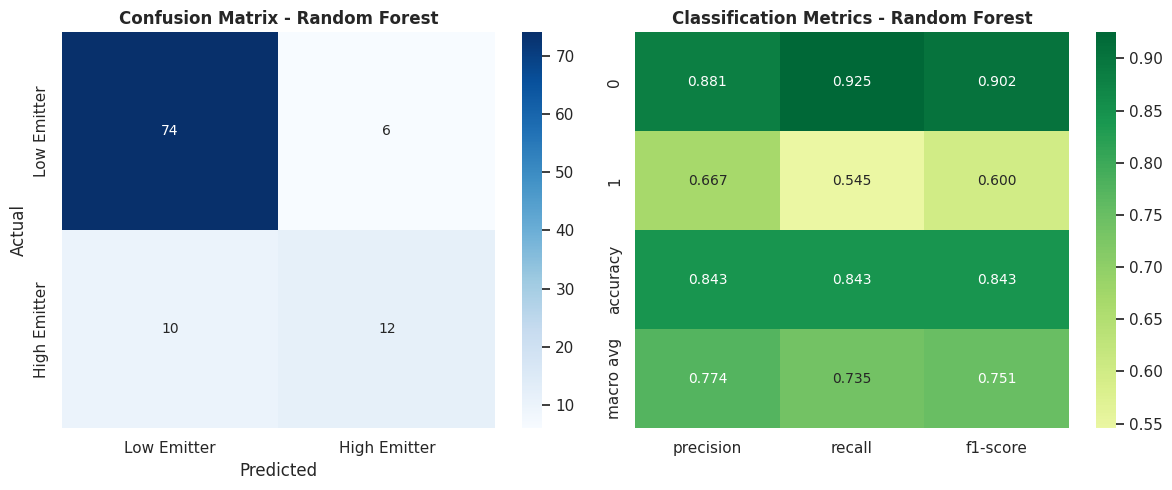

In [25]:


# Create classification target 
threshold = np.percentile(y, 75)
y_class = (y > threshold).astype(int)

print(f" Classification Setup:")
print(f"   Threshold: {threshold:.0f} MT CO₂e (75th percentile)")
print(f"   High emitters: {y_class.sum()} ({y_class.mean()*100:.1f}%)")
print(f"   Low emitters: {(y_class==0).sum()} ({(1-y_class.mean())*100:.1f}%)")

# Split for classification
X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(X, y_class, test_size=0.2, random_state=42)
X_train_cls_scaled = scaler.fit_transform(X_train_cls)
X_test_cls_scaled = scaler.transform(X_test_cls)

# Classification models
classification_models = {
    'Random Forest': RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1),
    'XGBoost': XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42, n_jobs=-1),
    'LightGBM': LGBMClassifier(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42, n_jobs=-1, verbose=-1)
}

classification_results = {}

for name, model in classification_models.items():
    # Cross-validation
    cv_auc = cross_val_score(model, X_train_cls_scaled, y_train_cls, cv=5, scoring='roc_auc')
    
    # Train
    model.fit(X_train_cls_scaled, y_train_cls)
    
    # Predict
    y_pred_proba = model.predict_proba(X_test_cls_scaled)[:, 1]
    y_pred = model.predict(X_test_cls_scaled)
    
    # Metrics
    auc = roc_auc_score(y_test_cls, y_pred_proba)
    accuracy = (y_pred == y_test_cls).mean()
    
    classification_results[name] = {
        'CV_AUC_mean': cv_auc.mean(),
        'CV_AUC_std': cv_auc.std(),
        'Test_AUC': auc,
        'Test_Accuracy': accuracy
    }
    
    print(f"\n   {name}:")
    print(f"     CV AUC: {cv_auc.mean():.4f} (±{cv_auc.std():.4f})")
    print(f"     Test AUC: {auc:.4f}")
    print(f"     Test Accuracy: {accuracy:.4f}")

best_classifier = max(classification_results, key=lambda x: classification_results[x]['Test_AUC'])
print(f"\n Best Classifier: {best_classifier}")
print(f"   Test AUC: {classification_results[best_classifier]['Test_AUC']:.4f}")

# Confusion Matrix for best classifier
best_clf = classification_models[best_classifier]
best_clf.fit(X_train_cls_scaled, y_train_cls)
y_pred_best = best_clf.predict(X_test_cls_scaled)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Confusion Matrix
cm = confusion_matrix(y_test_cls, y_pred_best)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_xlabel('Predicted', fontsize=12)
axes[0].set_ylabel('Actual', fontsize=12)
axes[0].set_title(f'Confusion Matrix - {best_classifier}', fontsize=12, fontweight='bold')
axes[0].set_xticklabels(['Low Emitter', 'High Emitter'])
axes[0].set_yticklabels(['Low Emitter', 'High Emitter'])

# Classification Report
report = classification_report(y_test_cls, y_pred_best, output_dict=True)
report_df = pd.DataFrame(report).transpose().iloc[:-1, :]
sns.heatmap(report_df[['precision', 'recall', 'f1-score']], annot=True, fmt='.3f', 
            cmap='RdYlGn', center=0.5, ax=axes[1])
axes[1].set_title(f'Classification Metrics - {best_classifier}', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

# FEATURE IMPORTANCE ANALYSIS

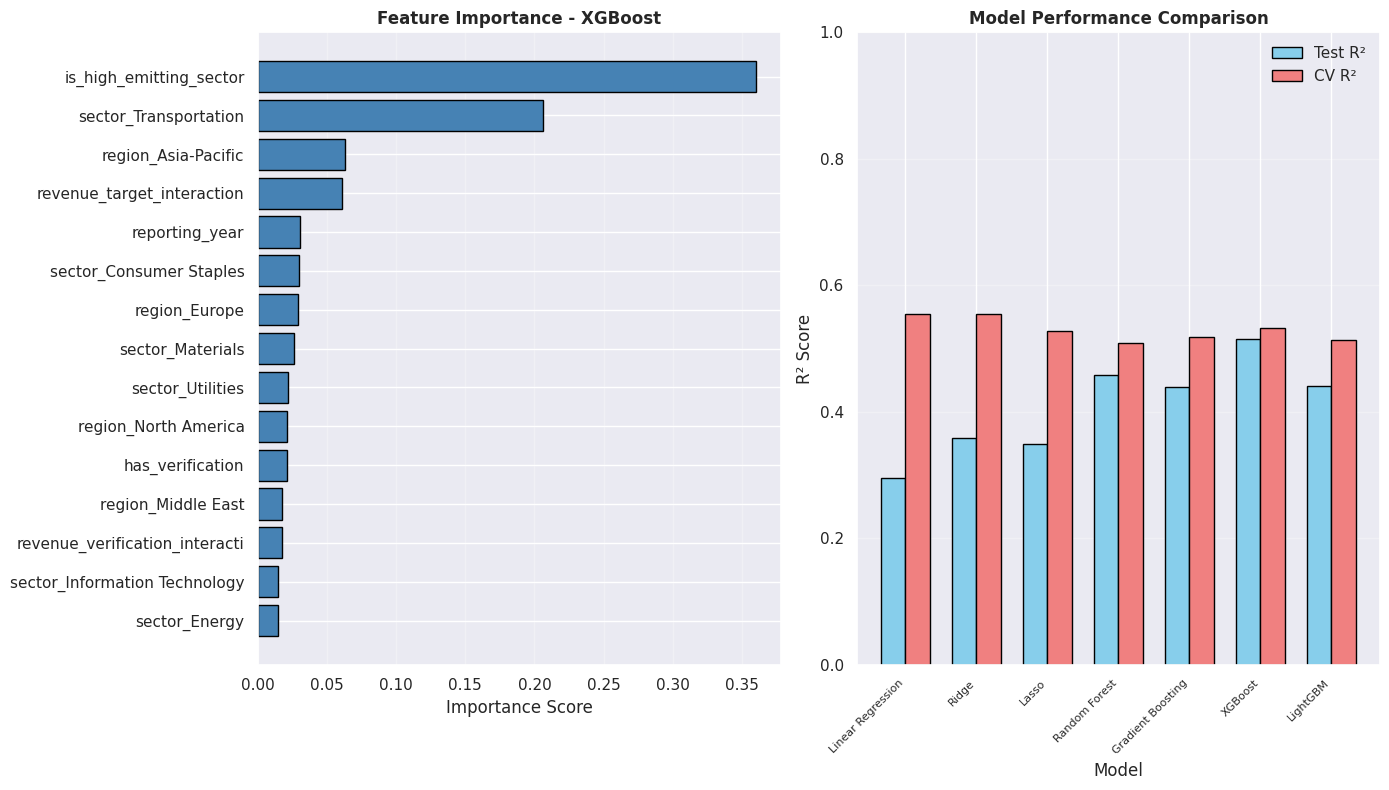


 Top 10 Most Important Features:
   1. is_high_emitting_sector: 0.3600
   2. sector_Transportation: 0.2062
   3. region_Asia-Pacific: 0.0632
   4. revenue_target_interaction: 0.0611
   5. reporting_year: 0.0304
   6. sector_Consumer Staples: 0.0295
   7. region_Europe: 0.0294
   8. sector_Materials: 0.0260
   9. sector_Utilities: 0.0218
   10. region_North America: 0.0214


In [26]:

# Get best model
best_model = regression_models[best_regressor]
best_model.fit(X_train_scaled, y_train_log)

# Feature importance
if hasattr(best_model, 'feature_importances_'):
    importances = best_model.feature_importances_
elif best_regressor in ['Linear Regression', 'Ridge', 'Lasso']:
    importances = np.abs(best_model.coef_)
else:
    importances = np.ones(len(safe_feature_cols)) / len(safe_feature_cols)

indices = np.argsort(importances)[::-1]

# Plot feature importance
fig, axes = plt.subplots(1, 2, figsize=(14, 8))

# Bar plot
ax = axes[0]
top_n = min(15, len(importances))
bars = ax.barh(range(top_n), importances[indices[:top_n]][::-1], color='steelblue', edgecolor='black')
ax.set_yticks(range(top_n))
ax.set_yticklabels([safe_feature_cols[i][:30] for i in indices[:top_n]][::-1])
ax.set_xlabel('Importance Score', fontsize=12)
ax.set_title(f'Feature Importance - {best_regressor}', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')

# Model comparison
ax = axes[1]
model_names = list(regression_results.keys())
r2_scores = [regression_results[m]['Test_R2'] for m in model_names]
cv_scores = [regression_results[m]['CV_R2_mean'] for m in model_names]

x = np.arange(len(model_names))
width = 0.35
bars1 = ax.bar(x - width/2, r2_scores, width, label='Test R²', color='skyblue', edgecolor='black')
bars2 = ax.bar(x + width/2, cv_scores, width, label='CV R²', color='lightcoral', edgecolor='black')
ax.set_xlabel('Model', fontsize=12)
ax.set_ylabel('R² Score', fontsize=12)
ax.set_title('Model Performance Comparison', fontsize=12, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(model_names, rotation=45, ha='right', fontsize=8)
ax.legend()
ax.set_ylim(0, 1)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("\n Top 10 Most Important Features:")
for i, idx in enumerate(indices[:10]):
    print(f"   {i+1}. {safe_feature_cols[idx]}: {importances[idx]:.4f}")

# CLUSTERING ANALYSIS

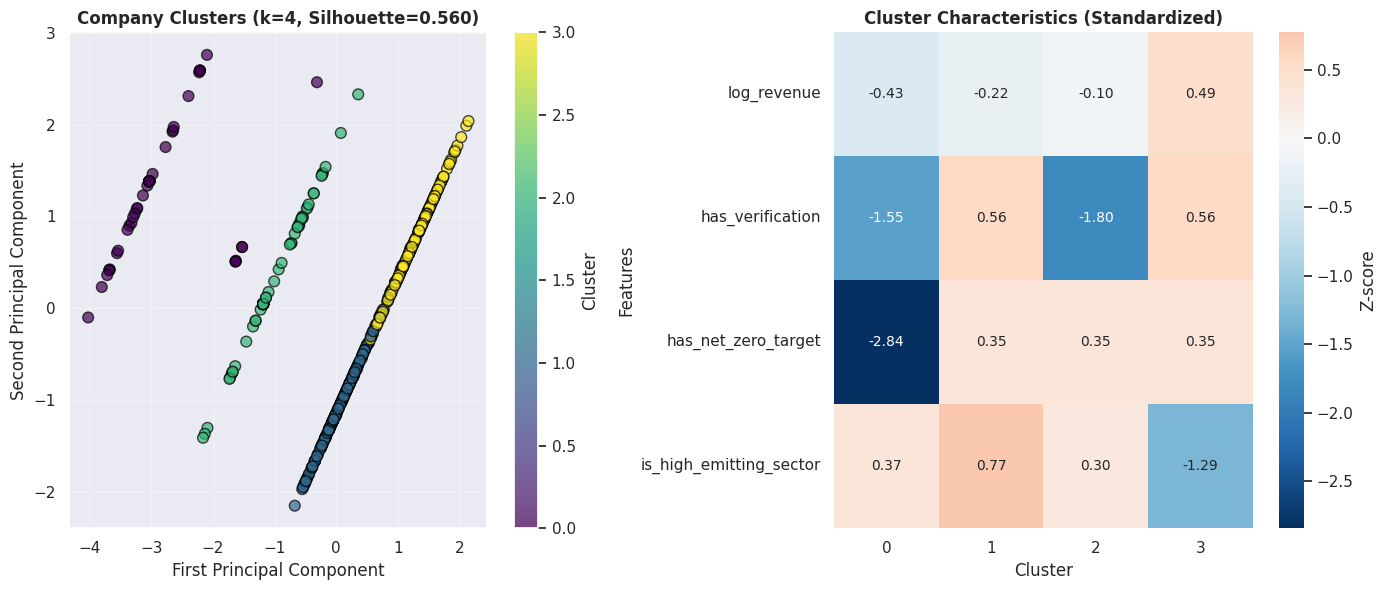


 Clustering Results:
   Optimal clusters: 4
   Silhouette score: 0.560

   Cluster Sizes:
     Cluster 0: 56 companies (11.0%)
     Cluster 1: 219 companies (43.1%)
     Cluster 2: 70 companies (13.8%)
     Cluster 3: 163 companies (32.1%)


In [27]:

# Select features for clustering (safe features only)
cluster_features = ['log_revenue', 'has_verification', 'has_net_zero_target', 'is_high_emitting_sector']
cluster_data = X[cluster_features].copy()

# Scale features
scaler_cluster = StandardScaler()
cluster_scaled = scaler_cluster.fit_transform(cluster_data)

# Find optimal clusters
silhouette_scores = []
K_range = range(2, 7)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(cluster_scaled)
    if len(np.unique(labels)) > 1:
        score = silhouette_score(cluster_scaled, labels)
        silhouette_scores.append(score)
    else:
        silhouette_scores.append(-1)

optimal_k = K_range[np.argmax(silhouette_scores)]

# Final clustering
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
clusters = kmeans_final.fit_predict(cluster_scaled)

# PCA for visualization
pca = PCA(n_components=2)
cluster_pca = pca.fit_transform(cluster_scaled)

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# PCA plot
ax = axes[0]
scatter = ax.scatter(cluster_pca[:, 0], cluster_pca[:, 1], c=clusters, cmap='viridis', 
                     s=60, alpha=0.7, edgecolors='black')
ax.set_xlabel('First Principal Component', fontsize=12)
ax.set_ylabel('Second Principal Component', fontsize=12)
ax.set_title(f'Company Clusters (k={optimal_k}, Silhouette={silhouette_scores[np.argmax(silhouette_scores)]:.3f})', 
             fontsize=12, fontweight='bold')
plt.colorbar(scatter, ax=ax, label='Cluster')
ax.grid(True, alpha=0.3)

# Cluster characteristics
ax = axes[1]
cluster_summary = pd.DataFrame(cluster_scaled, columns=cluster_features)
cluster_summary['Cluster'] = clusters
cluster_means = cluster_summary.groupby('Cluster').mean()

sns.heatmap(cluster_means.T, annot=True, fmt='.2f', cmap='RdBu_r', center=0, ax=ax,
            cbar_kws={'label': 'Z-score'})
ax.set_title('Cluster Characteristics (Standardized)', fontsize=12, fontweight='bold')
ax.set_xlabel('Cluster', fontsize=12)
ax.set_ylabel('Features', fontsize=12)

plt.tight_layout()
plt.show()

print(f"\n Clustering Results:")
print(f"   Optimal clusters: {optimal_k}")
print(f"   Silhouette score: {silhouette_scores[np.argmax(silhouette_scores)]:.3f}")
print(f"\n   Cluster Sizes:")
for i in range(optimal_k):
    size = (clusters == i).sum()
    print(f"     Cluster {i}: {size} companies ({size/len(clusters)*100:.1f}%)")

# PREDICTIONS VS ACTUALS ANALYSIS

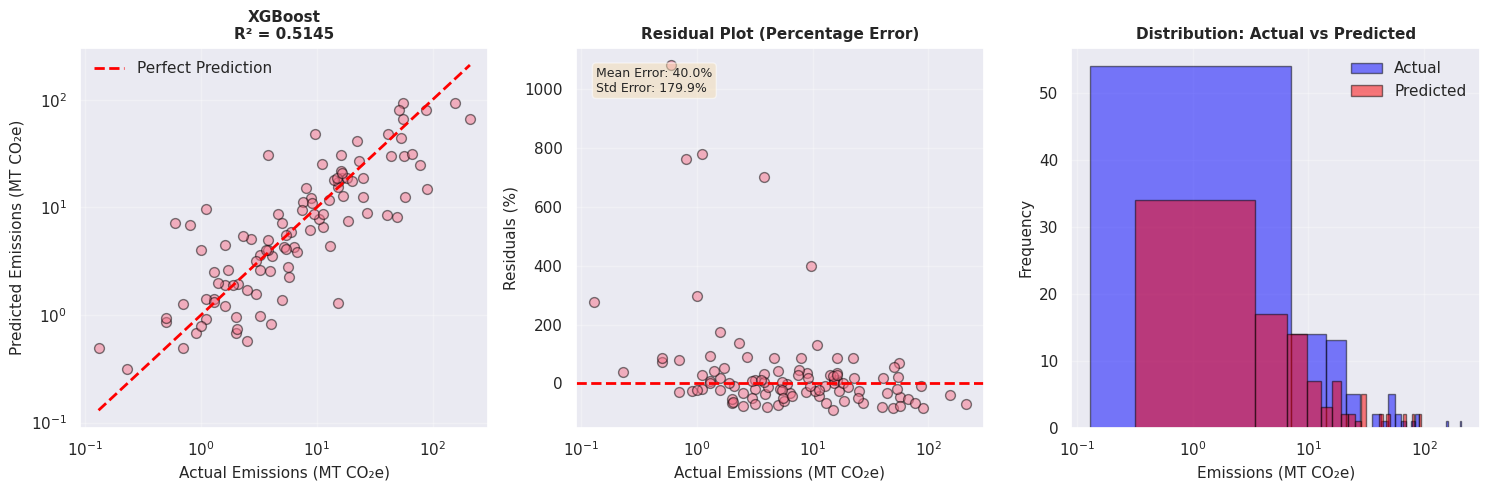


 Error Analysis by Emission Level:


,mean,std,count
emission_quantile,,,
Q1 (Lowest),138.27,290.63,26
Q2,20.75,151.82,25
Q3,23.02,90.44,26
Q4 (Highest),-25.19,48.35,25


In [28]:

# Best model predictions
best_model_final = regression_models[best_regressor]
best_model_final.fit(X_train_scaled, y_train_log)
y_pred_log = best_model_final.predict(X_test_scaled)
y_pred = np.expm1(y_pred_log)
y_test_actual = np.expm1(y_test_log)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Scatter plot
ax = axes[0]
ax.scatter(y_test_actual, y_pred, alpha=0.5, edgecolors='black', s=50)
ax.plot([y_test_actual.min(), y_test_actual.max()], 
         [y_test_actual.min(), y_test_actual.max()], 
         'r--', lw=2, label='Perfect Prediction')
ax.set_xlabel('Actual Emissions (MT CO₂e)', fontsize=11)
ax.set_ylabel('Predicted Emissions (MT CO₂e)', fontsize=11)
ax.set_title(f'{best_regressor}\nR² = {regression_results[best_regressor]["Test_R2"]:.4f}', 
             fontsize=11, fontweight='bold')
ax.set_xscale('log')
ax.set_yscale('log')
ax.legend()
ax.grid(True, alpha=0.3)

# Residuals plot
ax = axes[1]
residuals = y_pred - y_test_actual
residuals_pct = (residuals / y_test_actual) * 100
ax.scatter(y_test_actual, residuals_pct, alpha=0.5, edgecolors='black', s=50)
ax.axhline(y=0, color='r', linestyle='--', linewidth=2)
ax.set_xlabel('Actual Emissions (MT CO₂e)', fontsize=11)
ax.set_ylabel('Residuals (%)', fontsize=11)
ax.set_title('Residual Plot (Percentage Error)', fontsize=11, fontweight='bold')
ax.set_xscale('log')
ax.grid(True, alpha=0.3)
ax.text(0.05, 0.95, f'Mean Error: {np.mean(residuals_pct):.1f}%\nStd Error: {np.std(residuals_pct):.1f}%',
        transform=ax.transAxes, fontsize=9, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Distribution of predictions vs actuals
ax = axes[2]
ax.hist(y_test_actual, bins=30, alpha=0.5, label='Actual', color='blue', edgecolor='black')
ax.hist(y_pred, bins=30, alpha=0.5, label='Predicted', color='red', edgecolor='black')
ax.set_xlabel('Emissions (MT CO₂e)', fontsize=11)
ax.set_ylabel('Frequency', fontsize=11)
ax.set_title('Distribution: Actual vs Predicted', fontsize=11, fontweight='bold')
ax.set_xscale('log')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Error analysis by emission level
y_test_df = pd.DataFrame({'actual': y_test_actual, 'predicted': y_pred, 'error_pct': residuals_pct})
y_test_df['emission_quantile'] = pd.qcut(y_test_df['actual'], q=4, labels=['Q1 (Lowest)', 'Q2', 'Q3', 'Q4 (Highest)'])

print("\n Error Analysis by Emission Level:")
error_by_quantile = y_test_df.groupby('emission_quantile')['error_pct'].agg(['mean', 'std', 'count'])
display(error_by_quantile.round(2))

In [29]:


print("\n DATA QUALITY SUMMARY:")
print(f"   • Total companies: {df['company_id'].nunique()}")
print(f"   • Countries: {df['country'].nunique()}")
print(f"   • Reporting years: {sorted(df['reporting_year'].unique())}")
print(f"   • Third-party verified: {df['third_party_verified'].sum()} ({df['third_party_verified'].sum()/len(df)*100:.1f}%)")
print(f"   • With net-zero targets: {df['net_zero_target_year'].notna().sum()} ({df['net_zero_target_year'].notna().sum()/len(df)*100:.1f}%)")

print("\n MODEL PERFORMANCE:")
print(f"   • Best Regression Model: {best_regressor}")
print(f"     - R² Score: {regression_results[best_regressor]['Test_R2']:.4f}")
print(f"     - CV R²: {regression_results[best_regressor]['CV_R2_mean']:.4f}")
print(f"     - RMSE: {regression_results[best_regressor]['RMSE']:.2f} MT CO₂e")
print(f"     - MAPE: {regression_results[best_regressor]['MAPE']:.1f}%")
print(f"   • Best Classifier: {best_classifier}")
print(f"     - AUC-ROC: {classification_results[best_classifier]['Test_AUC']:.4f}")
print(f"     - CV AUC: {classification_results[best_classifier]['CV_AUC_mean']:.4f}")

print("\nTOP PREDICTORS (Feature Importance):")
for i, idx in enumerate(indices[:5]):
    print(f"   {i+1}. {safe_feature_cols[idx]}: {importances[idx]:.4f}")


# Calculate key insights
highest_emitting_sector = df.groupby('sector')['scope1_plus_scope2_location_mt'].mean().idxmax()
highest_emitting_region = df.groupby('region')['scope1_plus_scope2_location_mt'].mean().idxmax()
scope3_dominance = df['scope3_total_mt_co2e'].mean() / (df['scope1_mt_co2e'].mean() + df['scope2_location_mt_co2e'].mean() + df['scope3_total_mt_co2e'].mean()) * 100
correlation = df['revenue_usd_millions'].corr(df['scope1_plus_scope2_location_mt'])

print(f"   • Highest emitting sector: {highest_emitting_sector}")
print(f"   • Highest emitting region: {highest_emitting_region}")
print(f"   • Scope 3 accounts for {scope3_dominance:.1f}% of total emissions on average")
print(f"   • Revenue-Emissions correlation: {correlation:.3f}")
print(f"   • Most common net-zero target year: {df['net_zero_target_year'].mode().iloc[0]:.0f}")

print("\n VALIDATION CHECKS:")

print(f"    CV-Test gap: {abs(regression_results[best_regressor]['Test_R2'] - regression_results[best_regressor]['CV_R2_mean']):.4f}")




 DATA QUALITY SUMMARY:
   • Total companies: 508
   • Countries: 46
   • Reporting years: [np.int64(2021), np.int64(2022), np.int64(2023)]
   • Third-party verified: 388 (76.4%)
   • With net-zero targets: 452 (89.0%)

 MODEL PERFORMANCE:
   • Best Regression Model: XGBoost
     - R² Score: 0.5145
     - CV R²: 0.5324
     - RMSE: 21.42 MT CO₂e
     - MAPE: 82.7%
   • Best Classifier: Random Forest
     - AUC-ROC: 0.8960
     - CV AUC: 0.8448

TOP PREDICTORS (Feature Importance):
   1. is_high_emitting_sector: 0.3600
   2. sector_Transportation: 0.2062
   3. region_Asia-Pacific: 0.0632
   4. revenue_target_interaction: 0.0611
   5. reporting_year: 0.0304
   • Highest emitting sector: Energy
   • Highest emitting region: Africa
   • Scope 3 accounts for 90.4% of total emissions on average
   • Revenue-Emissions correlation: 0.143
   • Most common net-zero target year: 2050

 VALIDATION CHECKS:
    CV-Test gap: 0.0179
